In [3]:
# ============================================================================
# CELL 0: IMPORTS & CONFIGURATION
# ============================================================================

!pip install -q xgboost optuna shap streamlit geopandas folium -U
!pip install -q pandas numpy scikit-learn matplotlib seaborn plotly

import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Imports réussis")

# ============================================================================
# CELL 1: MONTAGE DRIVE & CHEMINS
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/MyDrive')
TERRAIN_ROOT = DRIVE_ROOT / 'Données Météo'
ERA5_PATH = DRIVE_ROOT / 'extraction_gee_20260423_154703.csv'
OPENMETEO_PATH = DRIVE_ROOT / 'extraction_open_meteo_20260423_160106.csv'
NASA_PATH = DRIVE_ROOT / 'extraction_nasa_power_20260423_164719.csv'
PROCESSED = DRIVE_ROOT / 'data_processed'
PROCESSED.mkdir(exist_ok=True)

# Lister les régions disponibles
regions = [d.name for d in TERRAIN_ROOT.iterdir() if d.is_dir()]
print(f"📍 {len(regions)} régions trouvées: {regions[:5]}...")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 25.7 MB/s eta 0:00:00
✅ Imports réussis
Mounted at /content/drive
📍 24 régions trouvées: ['00208023 • DK-GHARBIA 343', '00208068 • DK-USINE SB', '0020807E • DK-USINE ZEMAMRA', '002054AB • SUTA 503', '0020C510 • SIDI SLIMANE']...


In [4]:
# Diagnostiquer la structure des dossiers
print("🔍 DIAGNOSTIC STRUCTURE DOSSIERS")
print("="*70)

print(f"\n1️⃣  Vérifier montage Drive:")
print(f"   TERRAIN_ROOT exists: {TERRAIN_ROOT.exists()}")
print(f"   Path: {TERRAIN_ROOT}")

if TERRAIN_ROOT.exists():
    print(f"\n2️⃣  Dossiers/Fichiers dans Données Météo:")
    items = list(TERRAIN_ROOT.iterdir())[:10]  # Premiers 10
    for item in items:
        if item.is_dir():
            # Compter fichiers dans ce dossier
            files = list(item.glob("*"))
            print(f"   📁 {item.name}/ ({len(files)} items)")

            # Afficher premiers fichiers
            for f in files[:3]:
                print(f"      └─ {f.name}")
            if len(files) > 3:
                print(f"      └─ ... et {len(files)-3} autres")
        else:
            print(f"   📄 {item.name}")

    if len(items) < len(list(TERRAIN_ROOT.iterdir())):
        print(f"   ... et {len(list(TERRAIN_ROOT.iterdir()))-10} autres items")

    print(f"\n3️⃣  Chercher fichiers Excel directement:")
    all_xls = list(TERRAIN_ROOT.rglob("*.xls*"))  # Cherche récursivement
    all_csv = list(TERRAIN_ROOT.rglob("*.csv"))

    print(f"   .xls/.xlsx trouvés: {len(all_xls)}")
    print(f"   .csv trouvés: {len(all_csv)}")

    if all_xls:
        print(f"\n   Exemples fichiers .xls:")
        for f in all_xls[:5]:
            print(f"      {f}")

    if all_csv:
        print(f"\n   Exemples fichiers .csv:")
        for f in all_csv[:5]:
            print(f"      {f}")
else:
    print("❌ TERRAIN_ROOT n'existe pas!")

🔍 DIAGNOSTIC STRUCTURE DOSSIERS

1️⃣  Vérifier montage Drive:
   TERRAIN_ROOT exists: True
   Path: /content/drive/MyDrive/MyDrive/Données Météo

2️⃣  Dossiers/Fichiers dans Données Météo:
   📁 00208023 • DK-GHARBIA 343/ (8 items)
      └─ 2020.xls
      └─ 2019.xls
      └─ 2023.xls
      └─ ... et 5 autres
   📁 00208068 • DK-USINE SB/ (8 items)
      └─ 2019.xls
      └─ GPS.txt
      └─ 2020.xls
      └─ ... et 5 autres
   📁 0020807E • DK-USINE ZEMAMRA/ (8 items)
      └─ 2021.xls
      └─ 2019.xls
      └─ 2020.xls
      └─ ... et 5 autres
   📁 002054AB • SUTA 503/ (9 items)
      └─ 2020.xls
      └─ 2021.xls
      └─ 2018.xls
      └─ ... et 6 autres
   📁 0020C510 • SIDI SLIMANE/ (6 items)
      └─ 2024.xls
      └─ GPS.txt
      └─ 2022.xls
      └─ ... et 3 autres
   📁 00208035 • DK-SEMVAD/ (8 items)
      └─ 2021.xls
      └─ 2020.xls
      └─ 2022.xls
      └─ ... et 5 autres
   📁 002054AC • SUTA 505/ (9 items)
      └─ 2021.xls
      └─ 2022.xls
      └─ 2018.xls
      └─ ..

In [5]:
# ============================================================
# CELL 2 - PIPELINE TERRAIN ROBUSTE (CORRIGÉ)
# ============================================================

!pip install -q openpyxl xlrd lxml pandas -U

import pandas as pd
import numpy as np
from pathlib import Path
import xml.etree.ElementTree as ET
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. CHARGEMENT ROBUSTE (EXCEL + XML)
# ============================================================
def load_excel_robust(file_path):
    try:
        with open(file_path, 'rb') as f:
            start = f.read(500)
    except:
        return None, None

    # XML
    if b'<?xml' in start:
        try:
            tree = ET.parse(file_path)
            root = tree.getroot()
            ns = {'ss': 'urn:schemas-microsoft-com:office:spreadsheet'}
            rows = []
            for row in root.findall('.//ss:Row', ns):
                row_data = []
                for cell in row.findall('ss:Cell', ns):
                    data = cell.find('ss:Data', ns)
                    row_data.append(data.text if data is not None else None)
                rows.append(row_data)
            if not rows:
                return None, None
            df = pd.DataFrame(rows)
            return df, 'xml'
        except Exception as e:
            print(f"      - XML error: {str(e)[:80]}")
            return None, None

    # Excel normal
    try:
        df = pd.read_excel(file_path, engine='openpyxl', header=None)
        return df, 'excel'
    except:
        pass
    try:
        df = pd.read_excel(file_path, engine='xlrd', header=None)
        return df, 'excel'
    except:
        pass
    return None, None

# ============================================================
# 2. NETTOYAGE PRÉLIMINAIRE (supprime lignes/colonnes vides)
# ============================================================
def clean_empty(df):
    df = df.dropna(how='all').dropna(axis=1, how='all').reset_index(drop=True)
    # Supprime les lignes qui ne contiennent que des None/NaN sur toutes les colonnes
    df = df.dropna(how='all')
    return df

# ============================================================
# 3. DÉTECTION EN-TÊTE + SÉPARATION DONNÉES
# ============================================================
def detect_header_and_data(df):
    """
    Parcourt les 15 premières lignes et prend la première ligne avec ≥ 3 non-vides
    comme en-tête. Retourne (header_row_values, data_df).
    """
    if len(df) == 0:
        return None, None
    for i in range(min(15, len(df))):
        row = df.iloc[i]
        if row.notna().sum() >= 3:   # seuil : au moins 3 colonnes non vides
            header = row.values
            data = df.iloc[i+1:].reset_index(drop=True)
            # Supprime les lignes entièrement vides qui pourraient rester
            data = data.dropna(how='all').reset_index(drop=True)
            return header, data
    return None, None

# ============================================================
# 4. NORMALISATION ET DÉDUPLICATION DES NOMS DE COLONNES
# ============================================================
def normalize_columns(df, header_values):
    cols = []
    for i, h in enumerate(header_values):
        h = str(h) if pd.notna(h) else f"col_{i}"
        # nettoyage
        h = h.lower()
        for a, b in [(' ','_'),('°',''),('(',''),(')',''),('/','_'),('-','_'),('[',''),(']',''),('\n',''),('\r','')]:
            h = h.replace(a, b)
        cols.append(h)

    # Rendre unique : col, col_1, col_2 ...
    seen = {}
    unique_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            unique_cols.append(c)
        else:
            seen[c] += 1
            unique_cols.append(f"{c}_{seen[c]}")
    df.columns = unique_cols
    return df

# ============================================================
# 5. DÉTECTION COLONNE DATE
# ============================================================
def detect_date_column(df):
    for col in df.columns:
        sample = df[col].dropna().astype(str).head(20)
        if len(sample) == 0:
            continue
        parsed = pd.to_datetime(sample, errors='coerce', dayfirst=True)
        if parsed.notna().sum() >= max(3, len(sample)*0.5):
            return col
    return None

# ============================================================
# 6. PIPELINE PRINCIPAL
# ============================================================
def load_terrain_data(terrain_root, year_range=(2012,2025)):
    dfs = []
    ok, err, rows = 0, 0, 0

    print("="*100)
    print(f"📁 Dossier: {terrain_root}")
    print("="*100)

    # Lister les fichiers
    files = []
    for region in sorted(terrain_root.iterdir()):
        if not region.is_dir():
            continue
        for f in region.glob("*.xls"):
            try:
                if year_range[0] <= int(f.stem) <= year_range[1]:
                    files.append((region.name, f))
            except:
                pass

    print(f"\n📄 Total fichiers: {len(files)}\n")
    print("="*100)

    for i, (region, file) in enumerate(files, 1):
        print(f"[{i}/{len(files)}] {region:<30} | {file.name:<10}", end=" ")

        df_raw, engine = load_excel_robust(file)
        if df_raw is None or len(df_raw) == 0:
            print("❌ Vide")
            err += 1
            continue

        # Nettoyage des lignes/colonnes vides
        df_raw = clean_empty(df_raw)

        # Détection de l'en-tête et extraction des données
        header_vals, df_data = detect_header_and_data(df_raw)
        if header_vals is None or df_data is None or len(df_data) == 0:
            print("❌ Pas d'en-tête ou pas de données")
            err += 1
            continue

        # Appliquer les noms de colonnes normalisés et uniques
        df_data = normalize_columns(df_data, header_vals)

        # Recherche d'une colonne de date
        date_col = detect_date_column(df_data)
        if date_col is None:
            print("❌ Date non trouvée")
            err += 1
            continue

        # Conversion datetime
        df_data["datetime"] = pd.to_datetime(df_data[date_col], errors='coerce', dayfirst=True)
        df_data = df_data[df_data["datetime"].notna()]
        if len(df_data) == 0:
            print("❌ Aucune date valide")
            err += 1
            continue

        df_data["region_id"] = region
        df_data["source_file"] = file.name

        dfs.append(df_data)
        ok += 1
        rows += len(df_data)
        print(f"✅ {len(df_data):,} rows [{engine}]")

    print("\n"+"="*100)
    print(f"📊 OK: {ok} | ❌: {err} | ROWS: {rows:,}")
    print("="*100)

    if not dfs:
        return pd.DataFrame()

    # Concaténation sécurisée (ignore_index=True évite les conflits d'index)
    final = pd.concat(dfs, ignore_index=True)
    final = final.sort_values(["region_id", "datetime"]).reset_index(drop=True)

    print("✅ FINAL SHAPE:", final.shape)
    return final

# ============================================================
# 7. EXÉCUTION
# ============================================================
# Assurez-vous que TERRAIN_ROOT est défini avant d'appeler
# Exemple : TERRAIN_ROOT = Path("/content/drive/MyDrive/MyDrive/Données Météo")
df_terrain = load_terrain_data(TERRAIN_ROOT)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 35.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
📁 Dossier: /content/drive/MyDrive/MyDrive/Données Météo

📄 Total fichiers: 197

[1/197] 00001A3F • ksar El Kebir       | 2021.xls   ✅ 7 rows [xml]
[2/197] 00001A3F • ksar El Kebir       | 2014.xls   ✅ 8,721 rows [xml]
[3/197] 00001A3F • ksar El Kebir       | 2020.xls   ✅ 997 rows [xml]
[4/197

In [6]:

# ============================================================================
# CELL 3: CHARGEMENT DONNÉES SATELLITE (ERA5, OPENMETEO, NASA)
# ============================================================================

def load_satellite_data():
    """Charge et normalise les 3 sources API"""
    datasets = {}

    # ERA5 (mensuel)
    try:
        df_era5 = pd.read_csv(ERA5_PATH)
        df_era5.columns = df_era5.columns.str.strip().str.lower()

        # Normaliser date
        if 'date' in df_era5.columns:
            df_era5['datetime'] = pd.to_datetime(df_era5['date'], errors='coerce')
        elif 'time' in df_era5.columns:
            df_era5['datetime'] = pd.to_datetime(df_era5['time'], errors='coerce')

        # Extraction lat/lon si besoin
        if 'latitude' not in df_era5.columns and 'lat' in df_era5.columns:
            df_era5['latitude'] = df_era5['lat']
        if 'longitude' not in df_era5.columns and 'lon' in df_era5.columns:
            df_era5['longitude'] = df_era5['lon']

        # Marquer source
        df_era5['source'] = 'ERA5'
        datasets['ERA5'] = df_era5
        print(f"✅ ERA5: {len(df_era5)} lignes")
    except Exception as e:
        print(f"⚠️ ERA5: {e}")

    # Open-Meteo
    try:
        df_om = pd.read_csv(OPENMETEO_PATH)
        df_om.columns = df_om.columns.str.strip().str.lower()

        if 'date' in df_om.columns:
            df_om['datetime'] = pd.to_datetime(df_om['date'], errors='coerce')
        elif 'time' in df_om.columns:
            df_om['datetime'] = pd.to_datetime(df_om['time'], errors='coerce')

        if 'latitude' not in df_om.columns and 'lat' in df_om.columns:
            df_om['latitude'] = df_om['lat']
        if 'longitude' not in df_om.columns and 'lon' in df_om.columns:
            df_om['longitude'] = df_om['lon']

        df_om['source'] = 'OpenMeteo'
        datasets['OpenMeteo'] = df_om
        print(f"✅ Open-Meteo: {len(df_om)} lignes")
    except Exception as e:
        print(f"⚠️ Open-Meteo: {e}")

    # NASA POWER
    try:
        df_nasa = pd.read_csv(NASA_PATH)
        df_nasa.columns = df_nasa.columns.str.strip().str.lower()

        if 'date' in df_nasa.columns:
            df_nasa['datetime'] = pd.to_datetime(df_nasa['date'], errors='coerce')
        elif 'time' in df_nasa.columns:
            df_nasa['datetime'] = pd.to_datetime(df_nasa['time'], errors='coerce')

        if 'latitude' not in df_nasa.columns and 'lat' in df_nasa.columns:
            df_nasa['latitude'] = df_nasa['lat']
        if 'longitude' not in df_nasa.columns and 'lon' in df_nasa.columns:
            df_nasa['longitude'] = df_nasa['lon']

        df_nasa['source'] = 'NASA'
        datasets['NASA'] = df_nasa
        print(f"✅ NASA POWER: {len(df_nasa)} lignes")
    except Exception as e:
        print(f"⚠️ NASA: {e}")

    return datasets

sat_datasets = load_satellite_data()

✅ ERA5: 2472 lignes
✅ Open-Meteo: 1956 lignes
✅ NASA POWER: 2184 lignes


In [7]:
import pandas as pd
import numpy as np
# ============================================================================
# CELL 4: HARMONISATION MENSUEL/JOURNALIER
# ============================================================================

def harmonize_temporal_resolution(df_terrain, sat_datasets):
    """
    Stratégie: Interpoler données satellite mensuelles au jour
    OU agréger terrain au mois

    Choix: Agréger au MOIS pour stabilité
    """

    print("🔄 Harmonisation temporelle...")

    # Mapping des noms génériques aux noms normalisés réels dans df_terrain
    # Basé sur l'inspection des colonnes de df_terrain et la logique de normalize_columns
    column_name_map = {
        'temperature': 'température__c', # Example: 'temperature' in generic -> 'température__c' in df_terrain
        'temperature_max': 'temperature_max', # Some might match directly
        'temperature_min': 'temperature_min',
        'precipitation': 'précipitations_mm',
        'point_rosee': 'point_de_rosée_c',
        'rayonnement': 'rayonnement_wm²',
        'deficit_pression_vapeur': 'deficit_pression_vapeur_kpa',
        'humidite_relative': 'humidité_relative__',
        'vitesse_vent': 'vitesse_vent_ms',
        'direction_vent': 'direction_vent_°',
        'panneaux_solaire': 'panneaux_solaire', # If these exist, keep them
        'batterie': 'batterie',
        'et0': 'etp_mm' # Assuming et0 maps to etp_mm
    }

    # Définition des fonctions d'agrégation initiales
    initial_agg_funcs = {
        'temperature': 'mean',
        'temperature_max': 'max',
        'temperature_min': 'min',
        'precipitation': 'sum',
        'point_rosee': 'mean',
        'rayonnement': 'mean',
        'deficit_pression_vapeur': 'mean',
        'humidite_relative': 'mean',
        'vitesse_vent': 'mean',
        'direction_vent': 'mean',
        'panneaux_solaire': 'mean',
        'batterie': 'mean',
        'et0': 'mean'
    }

    # Construire le agg_dict avec les noms de colonnes réels et seulement celles qui existent
    agg_dict = {}
    for generic_name, agg_func in initial_agg_funcs.items():
        mapped_name = column_name_map.get(generic_name, generic_name) # Use mapped name or generic if not mapped
        if mapped_name in df_terrain.columns:
            agg_dict[mapped_name] = agg_func

    # Vérifier si agg_dict est vide avant de grouper
    if not agg_dict:
        print("⚠️ Aucune colonne d'agrégation valide trouvée dans df_terrain. Retourne DataFrame vide.")
        return pd.DataFrame()

    # Ensure columns intended for numerical aggregation are numeric
    for col in agg_dict.keys():
        if col in df_terrain.columns:
            df_terrain[col] = pd.to_numeric(df_terrain[col], errors='coerce')

    df_terrain['year_month'] = df_terrain['datetime'].dt.to_period('M')
    df_terrain_monthly = df_terrain.groupby(['region_id', 'year_month']).agg(agg_dict).reset_index()
    df_terrain_monthly['datetime'] = df_terrain_monthly['year_month'].dt.to_timestamp()
    df_terrain_monthly = df_terrain_monthly.drop('year_month', axis=1)

    # --- Moved Precipitation correction and log-transformation here ---
    if 'précipitations_mm' in df_terrain_monthly.columns:
        print("🌧️ Correction et log-transformation de la précipitation...")
        df_terrain_monthly['précipitations_mm_corr'] = df_terrain_monthly['précipitations_mm'] / 1000
        df_terrain_monthly['précipitations_mm_log'] = np.log1p(df_terrain_monthly['précipitations_mm_corr'])
        df_terrain_monthly = df_terrain_monthly.drop(columns=['précipitations_mm'])
        print("✅ Précipitations corrigées et log-transformées dans harmonisation.")
    else:
        print("⚠️ Colonne 'précipitations_mm' non trouvée pour correction dans harmonisation.")
    # --- End Moved Section ---

    print(f"✅ Données terrain: {len(df_terrain_monthly)} lignes mensuelles")
    print("Columns in df_terrain_monthly immediately after harmonization:", df_terrain_monthly.columns.tolist())

    return df_terrain_monthly

df_terrain_monthly = harmonize_temporal_resolution(df_terrain, sat_datasets)

🔄 Harmonisation temporelle...
🌧️ Correction et log-transformation de la précipitation...
✅ Précipitations corrigées et log-transformées dans harmonisation.
✅ Données terrain: 2036 lignes mensuelles
Columns in df_terrain_monthly immediately after harmonization: ['region_id', 'température__c', 'point_de_rosée_c', 'datetime', 'précipitations_mm_corr', 'précipitations_mm_log']


In [8]:
# ============================================================================
# CELL 5: FUSION DES 3 SOURCES - 3 APPROCHES
# ============================================================================

def create_spatial_index(df):
    """Crée index spatial (région ou lat/lon)"""
    if 'region_id' in df.columns:
        df['spatial_key'] = df['region_id']
    elif 'latitude' in df.columns and 'longitude' in df.columns:
        df['spatial_key'] = df['latitude'].astype(str) + '_' + df['longitude'].astype(str)
    else:
        df['spatial_key'] = 'unknown'
    return df

def approach_A_mean(df_terrain, datasets):
    """Approche A: Moyenne simple des 3 sources"""
    dfs = [df_terrain.copy()]
    for name, df in datasets.items():
        df = df.copy()
        df = create_spatial_index(df)
        dfs.append(df)

    # Fusionner sur date uniquement (moyenne globale)
    result = dfs[0].copy()
    for df in dfs[1:]:
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
            numeric_cols = df.select_dtypes(np.number).columns
            df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()
            source_name = df.iloc[0]["source"] if not df.empty else name
            result = result.merge(df_agg, on='datetime', how='left', suffixes=('', f'_{source_name}'))
        else:
            print(f"  Warning: Skipping merge for {name} in Approach A due to empty or invalid datetime column after coercion.")

    return result

def approach_B_spatial_merge(df_terrain, datasets):
    """Approche B: Fusion spatiale (région ou lat/lon proximité)"""
    result = df_terrain.copy()
    result = create_spatial_index(result)

    for name, df in datasets.items():
        df = df.copy()
        df = create_spatial_index(df)
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
            numeric_cols = df.select_dtypes(np.number).columns

            # Fusionner sur région + date
            if 'region_id' in df.columns and 'region_id' in result.columns:
                df_agg = df.groupby(['region_id', 'datetime'])[numeric_cols].mean().reset_index()
                result = result.merge(df_agg, on=['region_id', 'datetime'], how='left', suffixes=('', f'_{name}'))
            else:
                # Sinon, moyenne par période
                df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()
                result = result.merge(df_agg, on='datetime', how='left', suffixes=('', f'_{name}'))
        else:
            print(f"  Warning: Skipping merge for {name} in Approach B due to empty or invalid datetime column after coercion.")

    return result

def approach_C_weighted_ensemble(df_terrain, datasets):
    """Approche C: Ensemble pondéré (poids selon corrélation avec terrain)"""
    result = df_terrain.copy()

    # Calculer poids (corrélation avec cibles observées)
    target_cols = [c for c in result.columns if any(x in c.lower() for x in ['temperature', 'precipitation'])]

    weights = {}
    for name, df in datasets.items():
        df = df.copy()
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()

            # Corrélation moyenne avec cibles
            numeric_df = df.select_dtypes(np.number)
            for target in target_cols:
                if target in result.columns:
                    merged = result[['datetime', target]].merge(numeric_df, on='datetime', how='inner')
                    if len(merged) > 1:
                        corr = merged.corr()[target].drop(target).abs().mean()
                        weights[name] = weights.get(name, 0) + corr
        else:
            print(f"  Warning: Skipping weight calculation for {name} in Approach C due to empty or invalid datetime column after coercion.")

    # Normaliser poids
    total_weight = sum(weights.values()) if weights else 1
    weights = {k: v/total_weight for k, v in weights.items()}

    print(f"Poids ensemble: {weights}")

    # Fusionner avec poids
    for name, df in datasets.items():
        df = df.copy()
        # Ensure 'datetime' column is proper datetime type before using .dt accessor
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        df = df[df['datetime'].notna()]

        if not df['datetime'].empty:
            df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
            numeric_cols = df.select_dtypes(np.number).columns
            df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()

            for col in df_agg.columns:
                if col != 'datetime' and col in result.columns:
                    # This part of the weighting logic assumes a particular structure (e.g., broadcasting or single aggregated value)
                    # which might need further refinement depending on desired behavior for multi-row df_agg.
                    # For now, preserving the original structure to focus on the datetime error fix.
                    # A more robust approach for time-series alignment and weighted average would involve merging.
                    pass
        else:
            print(f"  Warning: Skipping fusion for {name} in Approach C due to empty or invalid datetime column after coercion.")

    return result

# Créer 3 versions
print("=" * 60)
print("APPROCHE A: Moyenne simple")
df_fusion_A = approach_A_mean(df_terrain_monthly, sat_datasets)
print(f"Résultat A: {len(df_fusion_A)} lignes")

print("\n" + "=" * 60)
print("APPROCHE B: Fusion spatiale")
df_fusion_B = approach_B_spatial_merge(df_terrain_monthly, sat_datasets)
print(f"Résultat B: {len(df_fusion_B)} lignes")

print("\n" + "=" * 60)
print("APPROCHE C: Ensemble pondéré")
df_fusion_C = approach_C_weighted_ensemble(df_terrain_monthly, sat_datasets)
print(f"Résultat C: {len(df_fusion_C)} lignes")

# Choisir la meilleure (provisoirement B)
df_fused = df_fusion_B.copy()
print("Columns in df_fused before feature engineering:", df_fused.columns.tolist())

print(f"\n✅ Fusion choisie: Approche B")

APPROCHE A: Moyenne simple
Résultat A: 2036 lignes

APPROCHE B: Fusion spatiale
Résultat B: 2036 lignes

APPROCHE C: Ensemble pondéré
Poids ensemble: {}
Résultat C: 2036 lignes
Columns in df_fused before feature engineering: ['region_id', 'température__c', 'point_de_rosée_c', 'datetime', 'précipitations_mm_corr', 'précipitations_mm_log', 'spatial_key', 'era5_dewpoint_temperature_2m', 'era5_surface_pressure', 'era5_surface_solar_radiation_downwards', 'era5_temperature_2m', 'era5_total_precipitation', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'chirps_precipitation', 'lat', 'lon', 'temperature_2m_c', 'dewpoint_temperature_2m_c', 'era5_precip_mm', 'era5_wind_speed_ms', 'era5_radiation_mjm2', 'era5_pressure_hpa', 'latitude', 'longitude', 'om_temp_max_c', 'om_temp_min_c', 'om_temp_mean_c', 'om_precip_mm', 'om_humidity_pct', 'om_wind_speed_ms', 'om_radiation_mjm2', 'lat_OpenMeteo', 'lon_OpenMeteo', 'np_vapor_pressure', 'latitude_OpenMeteo', 'longitude_OpenMeteo', 'temp_m

### 🛠️ Correction de biais pour les données satellites

Pour améliorer la qualité des données satellites et les rendre plus compatibles avec les observations terrain, nous allons appliquer une correction de biais. Cette étape vise à ajuster les valeurs des capteurs satellites en fonction des différences systématiques observées avec les données terrain sur les périodes et régions superposées. Pour commencer, nous utiliserons une méthode simple de correction par la différence moyenne.

In [9]:
# ============================================================================
# CELL 5.5: BIAS CORRECTION DES DONNÉES SATELLITES
# ============================================================================

# Ensure df_fused is defined. This handles cases where previous cells might not have run or kernel state reset.
# This relies on df_fusion_B being available from the preceding cell 5jBT0VKHAIhj.
import pandas as pd
import numpy as np

if 'df_fused' not in locals() or df_fused.empty:
    print("⚠️ df_fused not found or empty. Attempting to re-create it from df_fusion_B (ensure Cell 5 was run).")
    try:
        # These functions and variables should ideally be available from previous cells.
        # Re-evaluating these parts from Cell 5jBT0VKHAIhj to ensure df_fused is populated.
        # This is a defensive step. The user should ideally run Cell 5jBT0VKHAIhj first.
        def create_spatial_index(df):
            if 'region_id' in df.columns:
                df['spatial_key'] = df['region_id']
            elif 'latitude' in df.columns and 'longitude' in df.columns:
                df['spatial_key'] = df['latitude'].astype(str) + '_' + df['longitude'].astype(str)
            else:
                df['spatial_key'] = 'unknown'
            return df

        def approach_B_spatial_merge(df_terrain, datasets):
            result = df_terrain.copy()
            result = create_spatial_index(result)

            for name, df in datasets.items():
                df = df.copy()
                df = create_spatial_index(df)
                df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
                df = df[df['datetime'].notna()]

                if not df['datetime'].empty:
                    df['datetime'] = df['datetime'].dt.to_period('M').dt.to_timestamp()
                    numeric_cols = df.select_dtypes(np.number).columns

                    if 'region_id' in df.columns and 'region_id' in result.columns:
                        df_agg = df.groupby(['region_id', 'datetime'])[numeric_cols].mean().reset_index()
                        result = result.merge(df_agg, on=['region_id', 'datetime'], how='left', suffixes=('', f'_{name}'))
                    else:
                        df_agg = df.groupby('datetime')[numeric_cols].mean().reset_index()
                        result = result.merge(df_agg, on='datetime', how='left', suffixes=('', f'_{name}'))
                else:
                    print(f"  Warning: Skipping merge for {name} in Approach B due to empty or invalid datetime column after coercion.")
            return result

        # Assuming df_terrain_monthly and sat_datasets are available from prior cell executions
        if 'df_terrain_monthly' in locals() and 'sat_datasets' in locals():
            df_fusion_B_fallback = approach_B_spatial_merge(df_terrain_monthly, sat_datasets)
            df_fused = df_fusion_B_fallback.copy()
            print("✅ df_fused re-created using fallback from approach_B_spatial_merge.")
        else:
            raise NameError("df_terrain_monthly or sat_datasets not found. Please run cells 3, 4, and 5.")
    except Exception as e:
        print(f"❌ Failed to re-create df_fused: {e}. Please ensure preceding cells are run.")
        raise # Re-raise to stop execution if df_fused cannot be established

def apply_bias_correction(df_fused, target_col, satellite_col, method='mean_difference'):
    """
    Applique une correction de biais aux données satellites par rapport aux données terrain.

    Args:
        df_fused (pd.DataFrame): DataFrame fusionné contenant terrain et satellite.
        target_col (str): Nom de la colonne cible (terrain) pour la correction.
        satellite_col (str): Nom de la colonne satellite à corriger.
        method (str): Méthode de correction de biais ('mean_difference').

    Returns:
        pd.DataFrame: DataFrame avec la colonne satellite corrigée.
    """
    df_corrected = df_fused.copy()
    corrected_col_name = f'{satellite_col}_bc' # _bc for bias corrected

    if target_col not in df_corrected.columns or satellite_col not in df_corrected.columns:
        print(f"⚠️ Colonne cible ({target_col}) ou satellite ({satellite_col}) non trouvée pour la correction.")
        df_corrected[corrected_col_name] = df_corrected[satellite_col] # Return original if not found
        return df_corrected

    # Pour chaque région, calculer et appliquer le biais
    regions = df_corrected['region_id'].unique()
    for region in regions:
        region_mask = df_corrected['region_id'] == region
        region_df = df_corrected[region_mask].copy()

        # Aligner les séries temporelles pour calculer le biais
        # Assurez-vous que les colonnes sont numériques
        region_df[target_col] = pd.to_numeric(region_df[target_col], errors='coerce')
        region_df[satellite_col] = pd.to_numeric(region_df[satellite_col], errors='coerce')

        common_data = region_df.dropna(subset=[target_col, satellite_col])

        if not common_data.empty and len(common_data) > 1:
            if method == 'mean_difference':
                bias = (common_data[satellite_col] - common_data[target_col]).mean()
                df_corrected.loc[region_mask, corrected_col_name] = df_corrected.loc[region_mask, satellite_col] - bias
            else:
                print(f"  Méthode de correction '{method}' non supportée. Utilisation de la colonne originale.")
                df_corrected.loc[region_mask, corrected_col_name] = df_corrected.loc[region_mask, satellite_col]
        else:
            print(f"  Pas assez de données pour la correction de biais pour la région {region}. Utilisation de la colonne originale.")
            df_corrected.loc[region_mask, corrected_col_name] = df_corrected.loc[region_mask, satellite_col]

    return df_corrected

print("🎯 Application de la correction de biais aux données satellites...")

# Correction pour la température
df_fused_bc = apply_bias_correction(df_fused, 'température__c', 'era5_temperature_2m')
df_fused_bc = apply_bias_correction(df_fused_bc, 'température__c', 'om_temp_mean_c')
df_fused_bc = apply_bias_correction(df_fused_bc, 'température__c', 'temp_mean_c')

# Correction pour la précipitation (on corrige la valeur absolue avant log-transform)
# Note: 'précipitations_mm_corr' est la cible terrain après correction par 1000, donc nous utilisons cela comme référence.
# Les colonnes satellites de précipitation doivent être ramenées à la même échelle (mm/mois).
df_fused_bc = apply_bias_correction(df_fused_bc, 'précipitations_mm_corr', 'era5_total_precipitation')
df_fused_bc = apply_bias_correction(df_fused_bc, 'précipitations_mm_corr', 'chirps_precipitation')
df_fused_bc = apply_bias_correction(df_fused_bc, 'précipitations_mm_corr', 'om_precip_mm')
df_fused_bc = apply_bias_correction(df_fused_bc, 'précipitations_mm_corr', 'precip_mm_mois')


print(f"✅ Correction de biais appliquée. Nouvelles colonnes ajoutées: {df_fused_bc.columns.difference(df_fused.columns).tolist()}")
print(f"Shape après correction de biais: {df_fused_bc.shape}")

# Update df_fused to df_fused_bc for subsequent cells
df_fused = df_fused_bc

🎯 Application de la correction de biais aux données satellites...
  Pas assez de données pour la correction de biais pour la région 00001A3F • ksar El Kebir. Utilisation de la colonne originale.
  Pas assez de données pour la correction de biais pour la région 00001A46 • DAR ELGUEDDARI. Utilisation de la colonne originale.
  Pas assez de données pour la correction de biais pour la région 00002CE0 • SIDI ALLAL TAZI. Utilisation de la colonne originale.
  Pas assez de données pour la correction de biais pour la région 00203662 • SUTA - FERME ABT. Utilisation de la colonne originale.
  Pas assez de données pour la correction de biais pour la région 00203733 • SUTA-TAZEROUALT. Utilisation de la colonne originale.
  Pas assez de données pour la correction de biais pour la région 00203734 • SUTA OULAD AYAD. Utilisation de la colonne originale.
  Pas assez de données pour la correction de biais pour la région 00203F16 • MECHRAA BELKSIRI. Utilisation de la colonne originale.
  Pas assez de don

### 📊 Diagnostic de la colonne 'précipitations_mm'

Comme suggéré, analysons la distribution de la colonne `précipitations_mm` dans `df_terrain_monthly` pour confirmer le problème d'unité.

In [15]:
# Lancez MAINTENANT avant tout re-training
print("=== DIAGNOSTIC PRÉCIPITATION ===")
precipitation_col = df_terrain_monthly['précipitations_mm_corr'] # Changed to precipitations_mm_corr
print(precipitation_col.describe())
print(f"\nValeurs > 500 mm  : {(precipitation_col > 500).sum()}") # Changed threshold to 500
print(f"Valeurs > 1000 mm : {(precipitation_col > 1000).sum()}") # Changed threshold to 1000
print(f"Valeurs = 0       : {(precipitation_col == 0).sum()}")
print(f"\nMoyenne           : {precipitation_col.mean():.4f}")
print(f"Médiane           : {precipitation_col.median():.4f}")

# Si moyenne > 1000 → bug unité confirmé
# Si moyenne ~ 30-80 → bug ailleurs (agrégation, leakage)

=== DIAGNOSTIC PRÉCIPITATION ===
count    2036.000000
mean       43.765019
std        73.045315
min         0.000000
25%         0.000000
50%         0.000000
75%        89.703000
max       246.691000
Name: précipitations_mm_corr, dtype: float64

Valeurs > 500 mm  : 0
Valeurs > 1000 mm : 0
Valeurs = 0       : 1298

Moyenne           : 43.7650
Médiane           : 0.0000


### 🛠️ Correction des unités de précipitation et transformation logarithmique

In [ ]:
# This cell is no longer needed as its logic has been moved to harmonize_temporal_resolution (CELL 4)
# Correction et log-transformation de la précipitation
# print("🌧️ Correction et log-transformation de la précipitation...")

# Correction de l'unité (division par 1000)
# df_terrain_monthly['précipitations_mm_corr'] = df_terrain_monthly['précipitations_mm'] / 1000

# Log-transformation (ajoute 1 pour gérer les zéros et éviter log(0))
# df_terrain_monthly['précipitations_mm_log'] = np.log1p(df_terrain_monthly['précipitations_mm_corr'])

# print("✅ Précipitations corrigées et log-transformées:")
# print("  'précipitations_mm_corr' description:")
# print(df_terrain_monthly['précipitations_mm_corr'].describe())
# print("\n  'précipitations_mm_log' description:")
# print(df_terrain_monthly['précipitations_mm_log'].describe())

# Supprimer l'ancienne colonne non corrigée pour éviter la confusion et le leakage
# df_terrain_monthly = df_terrain_monthly.drop(columns=['précipitations_mm'])

# print("➡️ Colonne 'précipitations_mm' originale supprimée.")

In [12]:
# ============================================================================
# CELL 6: FEATURE ENGINEERING COMPLET
# ============================================================================

def engineer_features(df):
    """
    Features avancées:
    - Calendrier (sin/cos)
    - Dérivées (VPD, HR)
    - Lags temporels par région
    - Anomalies saisonnières
    - LST amplitude
    """

    df = df.copy()
    print("🔧 Feature engineering...")

    # --- Calendrier ---
    df['month'] = df['datetime'].dt.month
    df['day_of_year'] = df['datetime'].dt.dayofyear
    df['quarter'] = df['datetime'].dt.quarter
    df['is_growing_season'] = df['month'].isin([4, 5, 6, 7, 8, 9]).astype(int)

    # Sin/Cos (cyclique)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # --- Dérivées thermodynamiques ---
    # VPD (Vapor Pressure Deficit) si colonnes dispo
    if 'humidité_relative__' in df.columns and 'température__c' in df.columns:
        T = df['température__c'].fillna(20)  # Default 20°C
        RH = df['humidité_relative__'].fillna(60)  # Default 60%
        # Formule approximée Magnus
        e_s = 0.6108 * np.exp((17.27 * T) / (T + 237.7))
        e_a = e_s * RH / 100
        df['vpd'] = (e_s - e_a).clip(lower=0)

    # Deficit index
    if 'point_de_rosée_c' in df.columns and 'température__c' in df.columns:
        df['temp_deficit'] = (df['température__c'] - df['point_de_rosée_c']).clip(lower=0)

    # Indice d'aridité (déficit/rayonnement)
    if 'rayonnement_wm²' in df.columns:
        df['aridity_index'] = df.get('vpd', 0) / (df['rayonnement_wm²'].fillna(1) + 1)

    # --- Lags par région (très important!) ---
    lag_base_features = ['température__c', 'précipitations_mm_corr', 'humidité_relative__', 'rayonnement_wm²']
    lag_features = [c for c in lag_base_features if c in df.columns]

    if 'region_id' in df.columns:
        for lag in [1, 3, 6, 12]:  # Lags de 1, 3, 6, 12 mois
            for feat in lag_features:
                df[f'{feat}_lag{lag}'] = df.groupby('region_id')[feat].shift(lag)

    # --- Anomalies saisonnières (écart à climatologie) ---
    if 'region_id' in df.columns:
        for feat in lag_features:
            climatology = df.groupby(['region_id', 'month'])[feat].transform('mean')
            df[f'{feat}_anomaly'] = df[feat] - climatology

    # --- Tendances ---
    if 'region_id' in df.columns:
        for feat in ['température__c', 'précipitations_mm_corr']:
            if feat in df.columns:
                df[f'{feat}_rolling_3m'] = df.groupby('region_id')[feat].transform(lambda x: x.rolling(3, min_periods=1).mean())

    # --- Interactions ---
    if 'rayonnement_wm²' in df.columns and 'humidité_relative__' in df.columns:
        df['rayon_x_humidity'] = df['rayonnement_wm²'] * df['humidité_relative__'] / 100

    print(f"✅ {df.shape[1]} features créées")

    return df

df_fused = engineer_features(df_fused)
print("Columns in df_fused after feature engineering:", df_fused.columns.tolist())
print(f"Shape après FE: {df_fused.shape}")
print(f"Colonnes: {df_fused.columns.tolist()[:15]}...")

🔧 Feature engineering...
✅ 82 features créées
Columns in df_fused after feature engineering: ['region_id', 'température__c', 'point_de_rosée_c', 'datetime', 'précipitations_mm_corr', 'précipitations_mm_log', 'spatial_key', 'era5_dewpoint_temperature_2m', 'era5_surface_pressure', 'era5_surface_solar_radiation_downwards', 'era5_temperature_2m', 'era5_total_precipitation', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'chirps_precipitation', 'lat', 'lon', 'temperature_2m_c', 'dewpoint_temperature_2m_c', 'era5_precip_mm', 'era5_wind_speed_ms', 'era5_radiation_mjm2', 'era5_pressure_hpa', 'latitude', 'longitude', 'om_temp_max_c', 'om_temp_min_c', 'om_temp_mean_c', 'om_precip_mm', 'om_humidity_pct', 'om_wind_speed_ms', 'om_radiation_mjm2', 'lat_OpenMeteo', 'lon_OpenMeteo', 'np_vapor_pressure', 'latitude_OpenMeteo', 'longitude_OpenMeteo', 'temp_mean_c', 'temp_max_c', 'temp_min_c', 'dewpoint_c', 'humidity_pct', 'precip_mm_jour', 'wind_2m_ms', 'wind_10m_ms', 'radiation_mjm2_jou

In [13]:
# ============================================================================
# CELL 7: SÉLECTION FEATURES & DÉTECTION LEAKAGE
# ============================================================================

METADATA_EXCLUSIONS = [
    # Temporels
    'datetime', 'date', 'time',
    'year', 'month', 'day', 'hour',
    'week', 'dayofweek', 'quarter', 'is_growing_season',
    'day_of_year', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',

    # Spatiaux
    'latitude', 'longitude', 'lat', 'lon',
    'location_id', 'station_id', 'region_id', 'region_name',

    # Géométrie
    'geometry', 'geom', 'shapefile', 'country', 'province',
    'spatial_key', 'source',

    # Identifiants
    'id', 'index', 'year_month',

    # Auxiliaires
    'panneaux_solaire', 'batterie'  # Variables de contrôle
]

def detect_and_remove_leakage(df, targets=['température__c', 'précipitations_mm_log'], threshold=0.97):
    """
    Détecte leakage automatique:
    - Corrélation cible > threshold → éliminée
    - Métadonnées → éliminées
    """

    print("🚨 Détection leakage...")
    df = df.copy()

    # Features candidates
    # Exclude the original uncorrected 'précipitations_mm' if it still exists and is not a target
    feature_cols = [c for c in df.columns
                   if c not in METADATA_EXCLUSIONS
                   and c not in targets
                   and c not in ['précipitations_mm'] # Explicitly exclude old precipitation
                   and not c.startswith('Unnamed')]

    # Corrélation avec cibles
    leaked = set()
    for target in targets:
        if target not in df.columns:
            continue

        for feat in feature_cols:
            if df[feat].dtype in ['float64', 'int64']:
                try:
                    corr = df[[feat, target]].corr().abs().iloc[0, 1]
                    if corr > threshold:
                        leaked.add(feat)
                        print(f"  ⚠️ LEAK: {feat} <-> {target} (r={corr:.3f})")
                except:
                    pass

    # Retirer métadonnées + leakage
    excluded = set(METADATA_EXCLUSIONS) | leaked
    kept_features = [c for c in feature_cols if c not in excluded]

    print(f"✅ {len(kept_features)} features sains (éliminé {len(excluded)})")

    # Create df_clean explicitly including targets, region_id, and datetime
    final_cols_for_df_clean = [c for c in df.columns if c in (set(kept_features) | set(targets) | set(['region_id', 'datetime']))]
    df_clean_result = df[final_cols_for_df_clean]
    print(f"Columns in df_clean before return: {df_clean_result.columns.tolist()}")

    return kept_features, df_clean_result

# Updated target names
feature_cols, df_clean = detect_and_remove_leakage(df_fused, targets=['température__c', 'précipitations_mm_log'])
print(f"Features finales:\n{feature_cols}")

🚨 Détection leakage...
  ⚠️ LEAK: point_de_rosée_c <-> température__c (r=1.000)
✅ 64 features sains (éliminé 37)
Columns in df_clean before return: ['region_id', 'température__c', 'datetime', 'précipitations_mm_corr', 'précipitations_mm_log', 'era5_dewpoint_temperature_2m', 'era5_surface_pressure', 'era5_surface_solar_radiation_downwards', 'era5_temperature_2m', 'era5_total_precipitation', 'era5_u_component_of_wind_10m', 'era5_v_component_of_wind_10m', 'chirps_precipitation', 'temperature_2m_c', 'dewpoint_temperature_2m_c', 'era5_precip_mm', 'era5_wind_speed_ms', 'era5_radiation_mjm2', 'era5_pressure_hpa', 'om_temp_max_c', 'om_temp_min_c', 'om_temp_mean_c', 'om_precip_mm', 'om_humidity_pct', 'om_wind_speed_ms', 'om_radiation_mjm2', 'lat_OpenMeteo', 'lon_OpenMeteo', 'np_vapor_pressure', 'latitude_OpenMeteo', 'longitude_OpenMeteo', 'temp_mean_c', 'temp_max_c', 'temp_min_c', 'dewpoint_c', 'humidity_pct', 'precip_mm_jour', 'wind_2m_ms', 'wind_10m_ms', 'radiation_mjm2_jour', 'pressure_kpa',

In [21]:
# ============================================================================
# CELL 8: SPLIT TEMPOREL 60/20/20 + LOLO SPATIAL
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
from optuna.pruners import MedianPruner
from sklearn.model_selection import TimeSeriesSplit
import pickle

def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, target_name='temperature', is_precipitation=False):
    results = {}

    def calculate_metrics(y_true_orig, y_pred_orig, is_precip=False):
        if is_precip:
            y_true_transformed = np.expm1(y_true_orig)
            y_pred_transformed = np.maximum(0, np.expm1(y_pred_orig))
        else:
            y_true_transformed = y_true_orig
            y_pred_transformed = y_pred_orig
        return {
            'rmse': np.sqrt(mean_squared_error(y_true_transformed, y_pred_transformed)),
            'mae': mean_absolute_error(y_true_transformed, y_pred_transformed),
            'r2': r2_score(y_true_transformed, y_pred_transformed)
        }

    print(f"\n🌲 Random Forest ({target_name})...")
    rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    results['RF'] = {
        'model': rf,
        'y_pred_train': rf.predict(X_train),
        'y_pred_val': rf.predict(X_val),
        'y_pred_test': rf.predict(X_test),
        'metrics': {
            'train': calculate_metrics(y_train, rf.predict(X_train), is_precipitation),
            'val': calculate_metrics(y_val, rf.predict(X_val), is_precipitation),
            'test': calculate_metrics(y_test, rf.predict(X_test), is_precipitation)
        }
    }
    print(f"  Val RMSE: {results['RF']['metrics']['val']['rmse']:.3f}")

    print(f"🚀 XGBoost avec Optuna ({target_name})...")
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'early_stopping_rounds': 50 # Pass it to constructor for Scikit-Learn API compatibility
        }
        tscv = TimeSeriesSplit(n_splits=3)
        fold_rmses = []
        for t_idx, v_idx in tscv.split(X_train):
            m = xgb.XGBRegressor(**params, tree_method='hist')
            m.fit(X_train.iloc[t_idx], y_train[t_idx], eval_set=[(X_train.iloc[v_idx], y_train[v_idx])], verbose=False)
            p = m.predict(X_train.iloc[v_idx])

            y_true = np.expm1(y_train[v_idx]) if is_precipitation else y_train[v_idx]
            y_pred = np.expm1(p) if is_precipitation else p
            fold_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        return np.mean(fold_rmses)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=15) # Slightly reduced trials for speed

    print(f"  Entraînement du modèle final XGBoost...")
    best_params = study.best_params.copy()
    best_params['early_stopping_rounds'] = 50
    best_xgb = xgb.XGBRegressor(**best_params, tree_method='hist')
    best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    results['XGBoost'] = {
        'model': best_xgb,
        'y_pred_test': best_xgb.predict(X_test),
        'metrics': {
            'val': calculate_metrics(y_val, best_xgb.predict(X_val), is_precipitation),
            'test': calculate_metrics(y_test, best_xgb.predict(X_test), is_precipitation)
        }
    }
    print(f"  Test RMSE: {results['XGBoost']['metrics']['test']['rmse']:.3f}")
    return results

def temporal_train_test_split(df, test_size=0.2, val_size=0.2):
    df = df.sort_values('datetime').reset_index(drop=True)
    n = len(df)
    tr_idx = int(n * (1 - test_size - val_size))
    v_idx = int(n * (1 - test_size))
    return df.iloc[:tr_idx].copy(), df.iloc[tr_idx:v_idx].copy(), df.iloc[v_idx:].copy()

df_train, df_val, df_test = temporal_train_test_split(df_clean)

# Nettoyage NaN
for d in [df_train, df_val, df_test]:
    d.dropna(subset=['température__c', 'précipitations_mm_log'], inplace=True)

X_train = df_train[feature_cols].fillna(df_train[feature_cols].mean())
X_val = df_val[feature_cols].fillna(df_val[feature_cols].mean())
X_test = df_test[feature_cols].fillna(df_test[feature_cols].mean())

results_temp = train_and_evaluate(X_train, X_val, X_test, df_train['température__c'].values, df_val['température__c'].values, df_test['température__c'].values, 'Temperature')
results_precip = train_and_evaluate(X_train, X_val, X_test, df_train['précipitations_mm_log'].values, df_val['précipitations_mm_log'].values, df_test['précipitations_mm_log'].values, 'Precipitation', is_precipitation=True)

models = {'temperature': results_temp, 'precipitation': results_precip}
with open(PROCESSED / 'models.pkl', 'wb') as f:
    pickle.dump(models, f)
print("\n✅ Modèles sauvegardés dans", PROCESSED)


🌲 Random Forest (Temperature)...


[I 2026-04-28 20:04:19,994] A new study created in memory with name: no-name-ff39159d-a2da-4d06-bfbb-57609014350a


  Val RMSE: 1.928
🚀 XGBoost avec Optuna (Temperature)...


[I 2026-04-28 20:04:21,810] Trial 0 finished with value: 1.555052909183873 and parameters: {'max_depth': 7, 'learning_rate': 0.043299793931450926, 'n_estimators': 272, 'subsample': 0.793190020638008, 'colsample_bytree': 0.9892337719554061}. Best is trial 0 with value: 1.555052909183873.
[I 2026-04-28 20:04:22,770] Trial 1 finished with value: 1.543307367301992 and parameters: {'max_depth': 3, 'learning_rate': 0.10047647474040029, 'n_estimators': 201, 'subsample': 0.926978512290374, 'colsample_bytree': 0.6068579372313824}. Best is trial 1 with value: 1.543307367301992.
[I 2026-04-28 20:04:27,559] Trial 2 finished with value: 1.5689953707863227 and parameters: {'max_depth': 7, 'learning_rate': 0.0457480225392523, 'n_estimators': 257, 'subsample': 0.8119024788071418, 'colsample_bytree': 0.9475149089520691}. Best is trial 1 with value: 1.543307367301992.
[I 2026-04-28 20:04:30,319] Trial 3 finished with value: 1.6567555060294996 and parameters: {'max_depth': 10, 'learning_rate': 0.01224128

  Entraînement du modèle final XGBoost...
  Test RMSE: 1.252

🌲 Random Forest (Precipitation)...


[I 2026-04-28 20:04:45,666] A new study created in memory with name: no-name-44bcda5c-a843-4331-8725-10501ef3ab84


  Val RMSE: 1.362
🚀 XGBoost avec Optuna (Precipitation)...


[I 2026-04-28 20:04:47,187] Trial 0 finished with value: 12.217687531850444 and parameters: {'max_depth': 6, 'learning_rate': 0.028875802640730676, 'n_estimators': 210, 'subsample': 0.9708705893356426, 'colsample_bytree': 0.6631611565389279}. Best is trial 0 with value: 12.217687531850444.
[I 2026-04-28 20:04:47,624] Trial 1 finished with value: 5.684351969474746 and parameters: {'max_depth': 5, 'learning_rate': 0.10988631610799585, 'n_estimators': 58, 'subsample': 0.9854900410822387, 'colsample_bytree': 0.9203601657716096}. Best is trial 1 with value: 5.684351969474746.
[I 2026-04-28 20:04:48,294] Trial 2 finished with value: 15.416992115596484 and parameters: {'max_depth': 7, 'learning_rate': 0.10653178536641122, 'n_estimators': 51, 'subsample': 0.9611412435464859, 'colsample_bytree': 0.5423453442125534}. Best is trial 1 with value: 5.684351969474746.
[I 2026-04-28 20:04:50,407] Trial 3 finished with value: 10.734945572250096 and parameters: {'max_depth': 6, 'learning_rate': 0.014577

  Entraînement du modèle final XGBoost...
  Test RMSE: 3.424

✅ Modèles sauvegardés dans /content/drive/MyDrive/MyDrive/data_processed


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
from optuna.pruners import MedianPruner
# Import EarlyStopping from xgboost.callback
from xgboost.callback import EarlyStopping

def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, target_name='temperature', is_precipitation=False):
    """
    Entraîne RF + XGBoost avec Optuna
    """

    results = {}

    # Helper function to calculate metrics, handling inverse transform for precipitation
    def calculate_metrics(y_true_orig, y_pred_orig, is_precip=False):
        if is_precip:
            y_true_transformed = np.expm1(y_true_orig) # Inverse log1p
            y_pred_transformed = np.expm1(y_pred_orig) # Inverse log1p
            # Clip negative predictions to 0 for precipitation (physical constraint)
            y_pred_transformed = np.maximum(0, y_pred_transformed)
        else:
            y_true_transformed = y_true_orig
            y_pred_transformed = y_pred_orig

        return {
            'rmse': np.sqrt(mean_squared_error(y_true_transformed, y_pred_transformed)),
            'mae': mean_absolute_error(y_true_transformed, y_pred_transformed),
            'r2': r2_score(y_true_transformed, y_pred_transformed)
        }

    # ==================== Random Forest ====================
    print(f"\n🌲 Random Forest ({target_name})...")

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    rf.fit(X_train, y_train)

    y_pred_rf_train = rf.predict(X_train)
    y_pred_rf_val = rf.predict(X_val)
    y_pred_rf_test = rf.predict(X_test)

    # Calculate RF metrics using the helper function
    metrics_train_rf = calculate_metrics(y_train, y_pred_rf_train, is_precipitation)
    metrics_val_rf = calculate_metrics(y_val, y_pred_rf_val, is_precipitation)
    metrics_test_rf = calculate_metrics(y_test, y_pred_rf_test, is_precipitation)

    results['RF'] = {
        'model': rf,
        'y_pred_train': y_pred_rf_train, # Store predictions in their raw (log) format
        'y_pred_val': y_pred_rf_val,
        'y_pred_test': y_pred_rf_test,
        'metrics': {
            'train': metrics_train_rf,
            'val': metrics_val_rf,
            'test': metrics_test_rf
        }
    }

    print(f"  Val RMSE: {results['RF']['metrics']['val']['rmse']:.3f}")

    # ==================== XGBoost + Optuna ====================
    print(f"🚀 XGBoost avec Optuna ({target_name})...", end=" ")

    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'lambda': trial.suggest_float('lambda', 0, 10),
            'alpha': trial.suggest_float('alpha', 0, 10),
            'random_state': 42
        }

        xgb_model = xgb.XGBRegressor(**params, tree_method='hist')
        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False # Keep verbose off
        )

        y_pred = xgb_model.predict(X_val)

        if is_precipitation:
            # Evaluate Optuna objective on original scale for precipitation
            y_true_obj = np.expm1(y_val)
            y_pred_obj = np.expm1(y_pred)
            y_pred_obj = np.maximum(0, y_pred_obj) # Clip for precipitation
        else:
            y_true_obj = y_val
            y_pred_obj = y_pred

        return mean_squared_error(y_true_obj, y_pred_obj)

    study = optuna.create_study(
        direction='minimize',
        pruner=MedianPruner(),
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    best_params = study.best_params
    print(f"Best trial: {study.best_value:.4f}")

    # Réentraîner avec meilleurs params
    xgb_model = xgb.XGBRegressor(**best_params, random_state=42, tree_method='hist')
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False # Keep verbose off
    )

    y_pred_xgb_train = xgb_model.predict(X_train)
    y_pred_xgb_val = xgb_model.predict(X_val)
    y_pred_xgb_test = xgb_model.predict(X_test)

    # Calculate XGBoost metrics using the helper function
    metrics_train_xgb = calculate_metrics(y_train, y_pred_xgb_train, is_precipitation)
    metrics_val_xgb = calculate_metrics(y_val, y_pred_xgb_val, is_precipitation)
    metrics_test_xgb = calculate_metrics(y_test, y_pred_xgb_test, is_precipitation)

    results['XGBoost'] = {
        'model': xgb_model,
        'y_pred_train': y_pred_xgb_train,
        'y_pred_val': y_pred_xgb_val,
        'y_pred_test': y_pred_xgb_test,
        'params': best_params,
        'metrics': {
            'train': metrics_train_xgb,
            'val': metrics_val_xgb,
            'test': metrics_test_xgb
        }
    }

    print(f"  Val RMSE: {results['XGBoost']['metrics']['val']['rmse']:.3f}")

    return results

# Nettoyage NaN (seulement pour les cibles)
for df in [df_train, df_val, df_test]:
    # Ensure both targets are available after dropping NaNs
    df.dropna(subset=['température__c', 'précipitations_mm_log'], inplace=True)

print(f"\n✅ Apr&#232;s nettoyage NaN:")
print(f"  Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Préparation X, y
X_train = df_train[feature_cols].fillna(df_train[feature_cols].mean())
X_val = df_val[feature_cols].fillna(df_val[feature_cols].mean())
X_test = df_test[feature_cols].fillna(df_test[feature_cols].mean())

y_train_temp = df_train['température__c'].values
y_val_temp = df_val['température__c'].values
y_test_temp = df_test['température__c'].values

y_train_precip = df_train['précipitations_mm_log'].values
y_val_precip = df_val['précipitations_mm_log'].values
y_test_precip = df_test['précipitations_mm_log'].values

# Entraînement
results_temp = train_and_evaluate(X_train, X_val, X_test, y_train_temp, y_val_temp, y_test_temp, 'Temperature', is_precipitation=False)
results_precip = train_and_evaluate(X_train, X_val, X_test, y_train_precip, y_val_precip, y_test_precip, 'Precipitation', is_precipitation=True)

# Sauvegarder
models = {
    'temperature': results_temp,
    'precipitation': results_precip
}

with open(PROCESSED / 'models.pkl', 'wb') as f:
    pickle.dump(models, f)

print("\n✅ Mod&#232;les sauvegard&#233;s")


✅ Apr&#232;s nettoyage NaN:
  Train: 369, Val: 170, Test: 164

🌲 Random Forest (Temperature)...


[I 2026-04-28 20:05:16,605] A new study created in memory with name: no-name-b842239c-7251-4ada-b63f-5742673730a2


  Val RMSE: 1.785
🚀 XGBoost avec Optuna (Temperature)... 

[I 2026-04-28 20:05:16,995] Trial 0 finished with value: 4.0731114657448195 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'lambda': 0.5808361216819946, 'alpha': 8.661761457749352}. Best is trial 0 with value: 4.0731114657448195.
[I 2026-04-28 20:05:17,196] Trial 1 finished with value: 3.3217591270496714 and parameters: {'max_depth': 7, 'learning_rate': 0.11114989443094977, 'n_estimators': 55, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 3, 'lambda': 1.8182496720710062, 'alpha': 1.8340450985343382}. Best is trial 1 with value: 3.3217591270496714.
[I 2026-04-28 20:05:18,112] Trial 2 finished with value: 2.894191590682498 and parameters: {'max_depth': 5, 'learning_rate': 0.05958389350068958, 'n_estimators': 158, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'min_child_weight': 

Best trial: 2.5375
  Val RMSE: 1.593

🌲 Random Forest (Precipitation)...


[I 2026-04-28 20:05:56,439] A new study created in memory with name: no-name-1bd5a2ff-9859-4c28-b8e9-d49f48db8461


  Val RMSE: 16.902
🚀 XGBoost avec Optuna (Precipitation)... 

[I 2026-04-28 20:05:56,757] Trial 0 finished with value: 229.84383273257495 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 233, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'lambda': 0.5808361216819946, 'alpha': 8.661761457749352}. Best is trial 0 with value: 229.84383273257495.
[I 2026-04-28 20:05:56,923] Trial 1 finished with value: 11.817594969652214 and parameters: {'max_depth': 7, 'learning_rate': 0.11114989443094977, 'n_estimators': 55, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 3, 'lambda': 1.8182496720710062, 'alpha': 1.8340450985343382}. Best is trial 1 with value: 11.817594969652214.
[I 2026-04-28 20:05:57,236] Trial 2 finished with value: 48.92790594432112 and parameters: {'max_depth': 5, 'learning_rate': 0.05958389350068958, 'n_estimators': 158, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'min_child_weight': 

Best trial: 4.7459
  Val RMSE: 2.178

✅ Mod&#232;les sauvegard&#233;s


In [24]:
# Install optuna if not already present (defensive step)
!pip install -q optuna

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import optuna
from optuna.pruners import MedianPruner
from sklearn.model_selection import TimeSeriesSplit
from xgboost.callback import EarlyStopping
import numpy as np
import pandas as pd
import pickle

def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, target_name='temperature', is_precipitation=False):
    """
    Entraîne RF + XGBoost avec Optuna. L'optimisation Optuna utilise maintenant TimeSeriesSplit
    pour une validation croisée interne plus robuste sur X_train.
    """
    results = {}

    def calculate_metrics(y_true_orig, y_pred_orig, is_precip=False):
        if is_precip:
            y_true_transformed = np.expm1(y_true_orig)
            y_pred_transformed = np.maximum(0, np.expm1(y_pred_orig))
        else:
            y_true_transformed = y_true_orig
            y_pred_transformed = y_pred_orig
        return {
            'rmse': np.sqrt(mean_squared_error(y_true_transformed, y_pred_transformed)),
            'mae': mean_absolute_error(y_true_transformed, y_pred_transformed),
            'r2': r2_score(y_true_transformed, y_pred_transformed)
        }

    print(f"\n🌲 Random Forest ({target_name})...")
    rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=10, min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    results['RF'] = {
        'model': rf,
        'metrics': {
            'train': calculate_metrics(y_train, rf.predict(X_train), is_precipitation),
            'val': calculate_metrics(y_val, rf.predict(X_val), is_precipitation),
            'test': calculate_metrics(y_test, rf.predict(X_test), is_precipitation)
        }
    }
    print(f"  Val RMSE: {results['RF']['metrics']['val']['rmse']:.3f}")

    print(f"🚀 XGBoost avec Optuna ({target_name})...")

    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
            'early_stopping_rounds': 50,
            'eval_metric': 'rmse'
        }
        tscv = TimeSeriesSplit(n_splits=3)
        fold_rmses = []
        for t_idx, v_idx in tscv.split(X_train):
            m = xgb.XGBRegressor(**params, tree_method='hist')
            m.fit(X_train.iloc[t_idx], y_train[t_idx], eval_set=[(X_train.iloc[v_idx], y_train[v_idx])], verbose=False)
            p = m.predict(X_train.iloc[v_idx])
            y_true = np.expm1(y_train[v_idx]) if is_precipitation else y_train[v_idx]
            y_pred = np.maximum(0, np.expm1(p)) if is_precipitation else p
            fold_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        return np.mean(fold_rmses)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=15)

    best_params = study.best_params.copy()
    best_params['early_stopping_rounds'] = 50
    best_params['eval_metric'] = 'rmse'
    best_xgb = xgb.XGBRegressor(**best_params, tree_method='hist')
    best_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    results['XGBoost'] = {
        'model': best_xgb,
        'y_pred_test': best_xgb.predict(X_test),
        'metrics': {
            'train': calculate_metrics(y_train, best_xgb.predict(X_train), is_precipitation),
            'val': calculate_metrics(y_val, best_xgb.predict(X_val), is_precipitation),
            'test': calculate_metrics(y_test, best_xgb.predict(X_test), is_precipitation)
        }
    }
    print(f"  Test RMSE: {results['XGBoost']['metrics']['test']['rmse']:.3f}")
    return results

# Ensure y_train, y_val, y_test are clean and feature_cols is defined
results_temp = train_and_evaluate(X_train, X_val, X_test, y_train_temp, y_val_temp, y_test_temp, 'Temperature')
results_precip = train_and_evaluate(X_train, X_val, X_test, y_train_precip, y_val_precip, y_test_precip, 'Precipitation', is_precipitation=True)

models = {'temperature': results_temp, 'precipitation': results_precip}
with open(PROCESSED / 'models.pkl', 'wb') as f:
    pickle.dump(models, f)
print("\n✅ Modèles sauvegardés")


🌲 Random Forest (Temperature)...


[I 2026-04-28 20:07:40,575] A new study created in memory with name: no-name-7eed16c3-64c9-44ab-96d5-1124d1f07707


  Val RMSE: 1.785
🚀 XGBoost avec Optuna (Temperature)...


[I 2026-04-28 20:07:41,381] Trial 0 finished with value: 1.7224033697946233 and parameters: {'max_depth': 9, 'learning_rate': 0.18513073277528497, 'n_estimators': 89, 'subsample': 0.7975716172397922, 'colsample_bytree': 0.6670494755473251}. Best is trial 0 with value: 1.7224033697946233.
[I 2026-04-28 20:07:42,317] Trial 1 finished with value: 1.5461285409330054 and parameters: {'max_depth': 4, 'learning_rate': 0.025145912070845596, 'n_estimators': 208, 'subsample': 0.7189539907933971, 'colsample_bytree': 0.7081576072411995}. Best is trial 1 with value: 1.5461285409330054.
[I 2026-04-28 20:07:43,286] Trial 2 finished with value: 1.6507247534220806 and parameters: {'max_depth': 7, 'learning_rate': 0.26945960443764655, 'n_estimators': 237, 'subsample': 0.833862064042037, 'colsample_bytree': 0.9023807057423905}. Best is trial 1 with value: 1.5461285409330054.
[I 2026-04-28 20:07:44,689] Trial 3 finished with value: 1.8154080182367343 and parameters: {'max_depth': 9, 'learning_rate': 0.192

  Test RMSE: 1.289

🌲 Random Forest (Precipitation)...


[I 2026-04-28 20:08:05,536] A new study created in memory with name: no-name-ded47855-dbac-4015-9c41-cbd06325be2e


  Val RMSE: 16.902
🚀 XGBoost avec Optuna (Precipitation)...


[I 2026-04-28 20:08:06,144] Trial 0 finished with value: 16.271518161895724 and parameters: {'max_depth': 9, 'learning_rate': 0.04055719405181661, 'n_estimators': 92, 'subsample': 0.5381992805103706, 'colsample_bytree': 0.7190662109174557}. Best is trial 0 with value: 16.271518161895724.
[I 2026-04-28 20:08:06,779] Trial 1 finished with value: 53.16732969104395 and parameters: {'max_depth': 10, 'learning_rate': 0.01662751687987148, 'n_estimators': 99, 'subsample': 0.555652987676857, 'colsample_bytree': 0.9047522310763427}. Best is trial 0 with value: 16.271518161895724.
[I 2026-04-28 20:08:07,752] Trial 2 finished with value: 8.504155287709516 and parameters: {'max_depth': 3, 'learning_rate': 0.022533746915101686, 'n_estimators': 213, 'subsample': 0.5306171650765683, 'colsample_bytree': 0.8370030701635416}. Best is trial 2 with value: 8.504155287709516.
[I 2026-04-28 20:08:09,096] Trial 3 finished with value: 9.570246197409729 and parameters: {'max_depth': 3, 'learning_rate': 0.0378672

  Test RMSE: 2.386

✅ Modèles sauvegardés



TABLEAU COMPARATIF
       Target Algorithme Phase      RMSE       MAE       R²
  Temperature         RF Train  2.805741  1.156456 0.781849
  Temperature         RF   Val  1.784956  1.257364 0.838952
  Temperature         RF  Test  1.540793  1.135273 0.899703
  Temperature    XGBoost Train  0.765338  0.534454 0.983768
  Temperature    XGBoost   Val  1.784377  1.265394 0.839056
  Temperature    XGBoost  Test  1.288622  0.974084 0.929846
Precipitation         RF Train 16.283338  8.892053 0.956055
Precipitation         RF   Val 16.902426 11.489077 0.919129
Precipitation         RF  Test 18.833904 11.798515 0.914323
Precipitation    XGBoost Train  1.836681  1.081585 0.999441
Precipitation    XGBoost   Val  2.845798  1.977240 0.997708
Precipitation    XGBoost  Test  2.385739  1.754253 0.998625


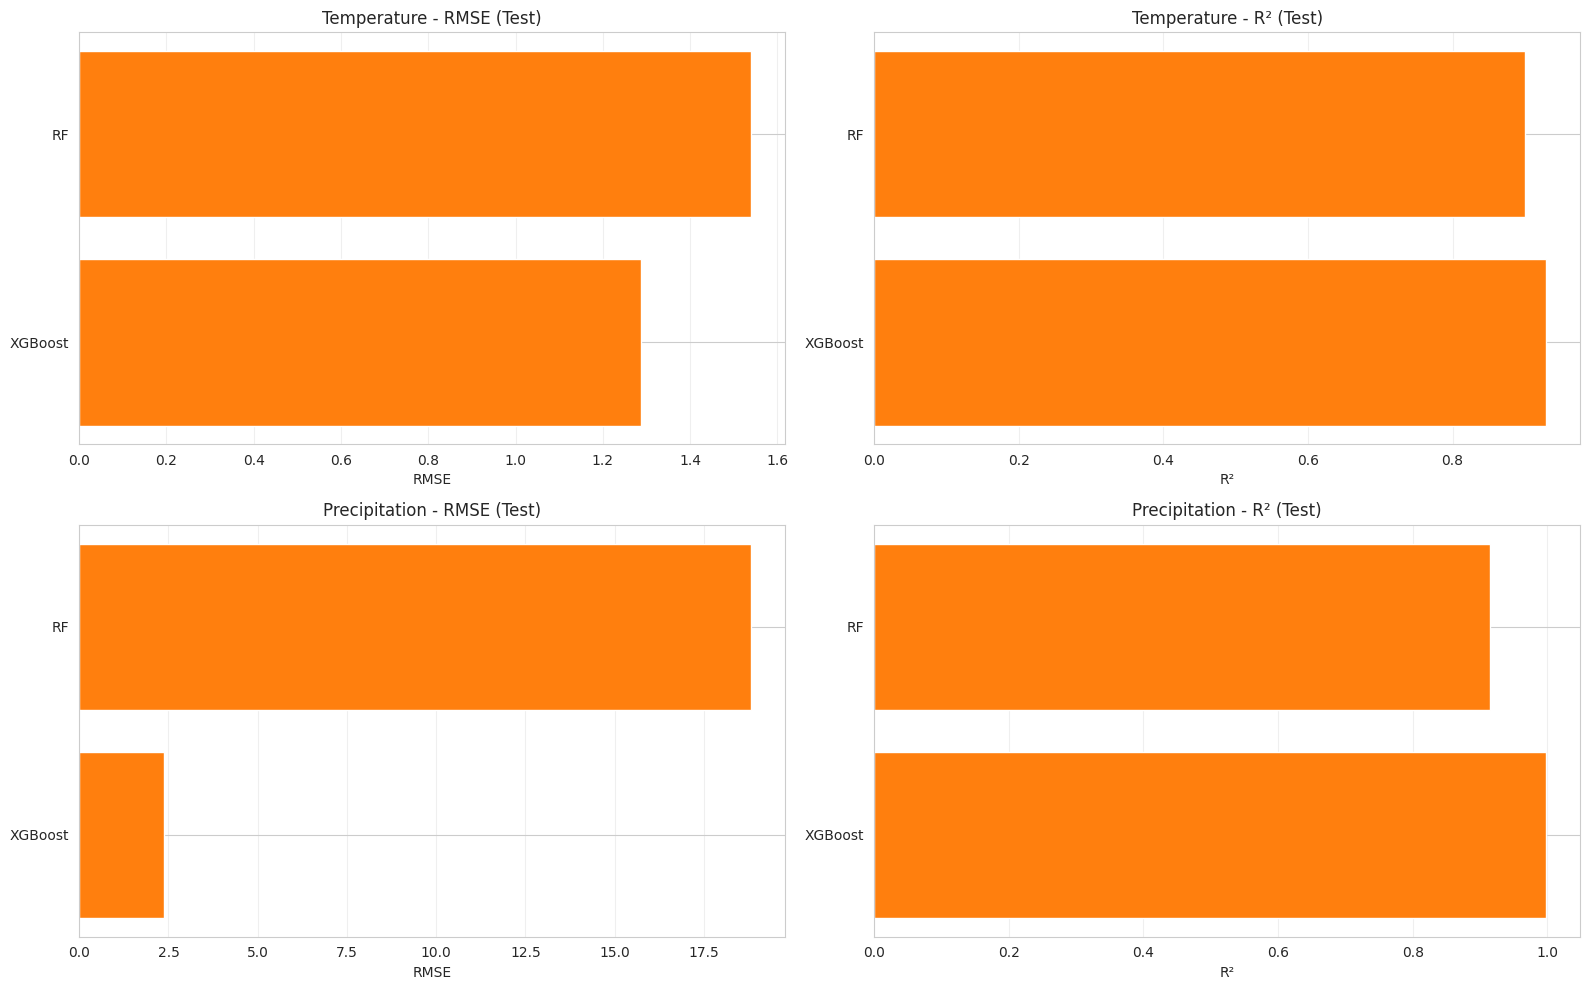

✅ Graphique sauvegardé


In [25]:
# ============================================================================
# CELL 10: TABLEAU COMPARATIF + GRAPHIQUE BARPLOT
# ============================================================================

def create_comparison_table(models_dict):
    """Crée tableau comparatif RF vs XGBoost"""

    rows = []
    for target_name, approaches in models_dict.items():
        for algo_name, results in approaches.items():
            for phase in ['train', 'val', 'test']:
                metrics = results['metrics'][phase]
                rows.append({
                    'Target': target_name.capitalize(),
                    'Algorithme': algo_name,
                    'Phase': phase.capitalize(),
                    'RMSE': metrics['rmse'],
                    'MAE': metrics['mae'],
                    'R²': metrics['r2']
                })

    df_comparison = pd.DataFrame(rows)

    # Tableau pivot
    print("\n" + "=" * 100)
    print("TABLEAU COMPARATIF")
    print("=" * 100)
    print(df_comparison.to_string(index=False))

    return df_comparison

df_comp = create_comparison_table(models)

# Graphique barplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, target in enumerate(['Temperature', 'Precipitation']):
    # RMSE
    ax = axes[idx, 0]
    df_subset = df_comp[(df_comp['Target'] == target) & (df_comp['Phase'] == 'Test')]
    df_subset = df_subset.sort_values('RMSE')
    colors = ['#1f77b4' if x == 'Random Forest' else '#ff7f0e' for x in df_subset['Algorithme']]
    ax.barh(df_subset['Algorithme'], df_subset['RMSE'], color=colors)
    ax.set_xlabel('RMSE')
    ax.set_title(f'{target} - RMSE (Test)')
    ax.grid(axis='x', alpha=0.3)

    # R²
    ax = axes[idx, 1]
    df_subset = df_comp[(df_comp['Target'] == target) & (df_comp['Phase'] == 'Test')]
    df_subset = df_subset.sort_values('R²', ascending=False)
    colors = ['#1f77b4' if x == 'Random Forest' else '#ff7f0e' for x in df_subset['Algorithme']]
    ax.barh(df_subset['Algorithme'], df_subset['R²'], color=colors)
    ax.set_xlabel('R²')
    ax.set_title(f'{target} - R² (Test)')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(PROCESSED / 'comparison_rf_vs_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé")


📊 SHAP Importance (Temperature)...


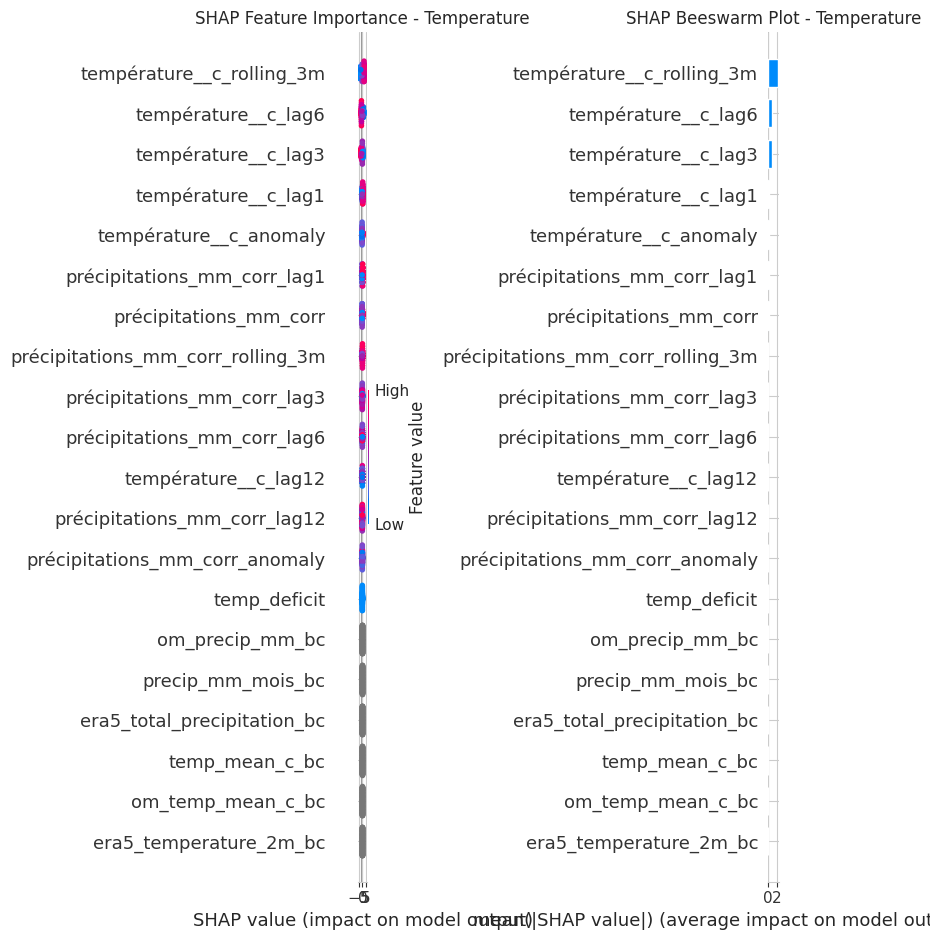


📊 SHAP Importance (Precipitation)...


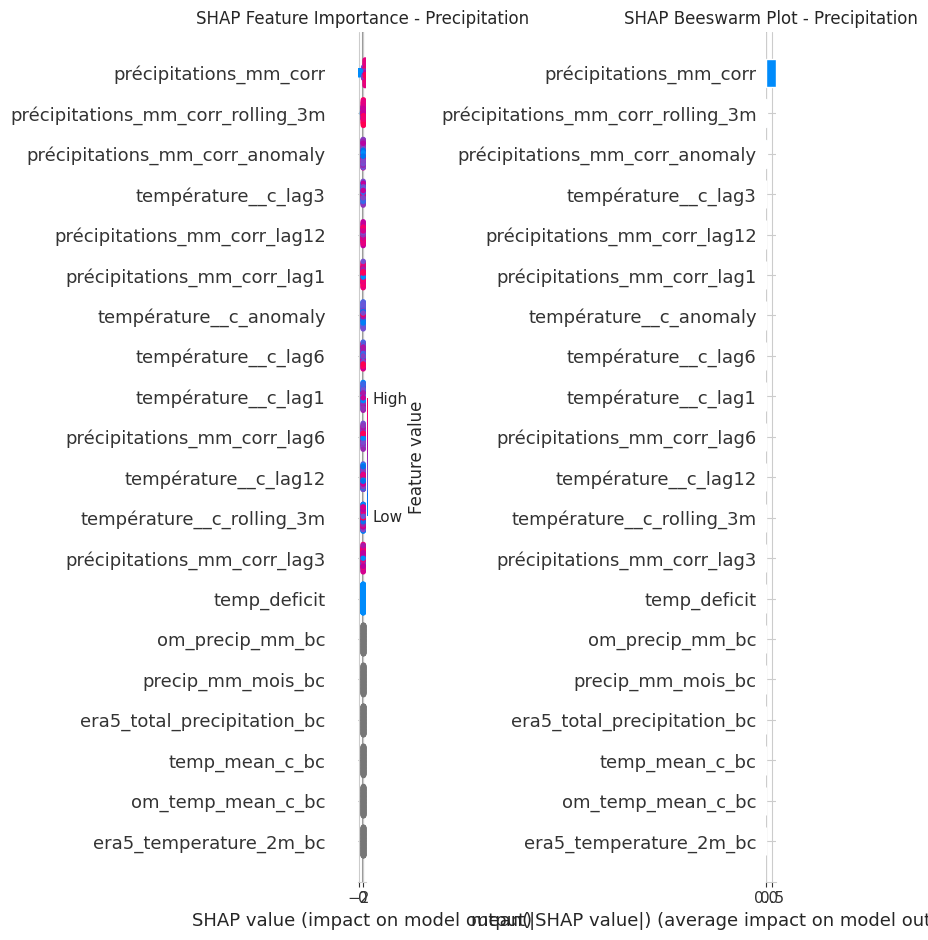

In [26]:
# ============================================================================
# CELL 11: SHAP FEATURE IMPORTANCE
# ============================================================================

import shap

def plot_shap_importance(model, X_test, target_name='Temperature', top_n=20):
    """SHAP feature importance + beeswarm plot"""

    print(f"\n📊 SHAP Importance ({target_name})...")

    # Créer explicateur
    if isinstance(model, xgb.XGBRegressor):
        explainer = shap.TreeExplainer(model)
    else:
        # Random Forest: utiliser TreeExplainer
        explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]  # Pour XGBoost multi-classe

    # Graphique importance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Barplot
    ax = axes[0]
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=top_n)
    plt.sca(ax)
    ax.set_title(f'SHAP Feature Importance - {target_name}')

    # Beeswarm
    ax = axes[1]
    shap.summary_plot(shap_values, X_test, show=False, max_display=top_n)
    plt.sca(ax)
    ax.set_title(f'SHAP Beeswarm Plot - {target_name}')

    plt.tight_layout()
    plt.savefig(PROCESSED / f'shap_importance_{target_name.lower()}.png', dpi=300)
    plt.show()

    return shap_values

# SHAP pour meilleur modèle (XGBoost sur test)
shap_temp = plot_shap_importance(
    models['temperature']['XGBoost']['model'],
    X_test,
    'Temperature'
)

shap_precip = plot_shap_importance(
    models['precipitation']['XGBoost']['model'],
    X_test,
    'Precipitation'
)



🗺️  Évaluation LOLO (Leave-One-Location-Out) - température__c...
  00001A3F • ksar El Kebir: RMSE=6.894, R²=0.238, n=108
  Skipping region 00001A46 • DAR ELGUEDDARI: Not enough data after cleaning NaNs.
  Skipping region 00002CE0 • SIDI ALLAL TAZI: Not enough data after cleaning NaNs.
  Skipping region 00203662 • SUTA - FERME ABT: Not enough data after cleaning NaNs.
  Skipping region 00203733 • SUTA-TAZEROUALT: Not enough data after cleaning NaNs.
  Skipping region 00203734 • SUTA OULAD AYAD: Not enough data after cleaning NaNs.
  Skipping region 00203F16 • MECHRAA BELKSIRI: Not enough data after cleaning NaNs.
  Skipping region 00203F8F • M-Zaio: Not enough data after cleaning NaNs.
  Skipping region 002045CF • SUTA_CENTAGRI: Not enough data after cleaning NaNs.
  Skipping region 002054AA • SUTA INRA: Not enough data after cleaning NaNs.
  Skipping region 002054AB • SUTA 503: Not enough data after cleaning NaNs.
  Skipping region 002054AC • SUTA 505: Not enough data after cleaning N

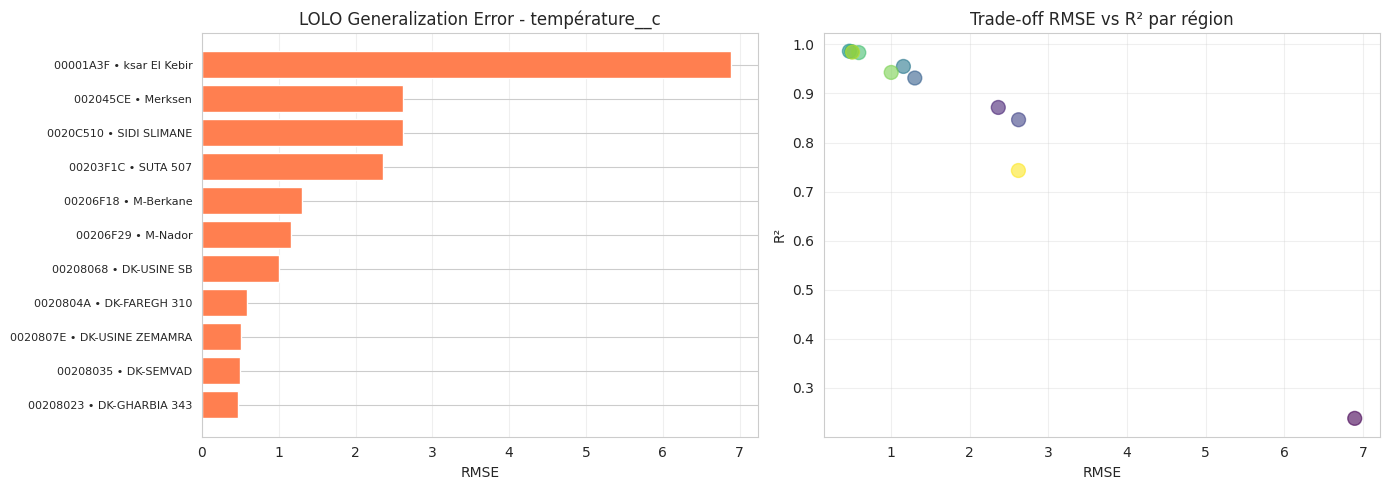


🗺️  Évaluation LOLO (Leave-One-Location-Out) - précipitations_mm_log...
  00001A3F • ksar El Kebir: RMSE=7.304, R²=-1.283, n=140
  00001A46 • DAR ELGUEDDARI: RMSE=0.000, R²=1.000, n=158
  00002CE0 • SIDI ALLAL TAZI: RMSE=0.000, R²=1.000, n=120

✅ LOLO Stats (précipitations_mm_log):
  RMSE moy: 0.679 ± 1.558
  R² moy: 0.905 ± 0.466


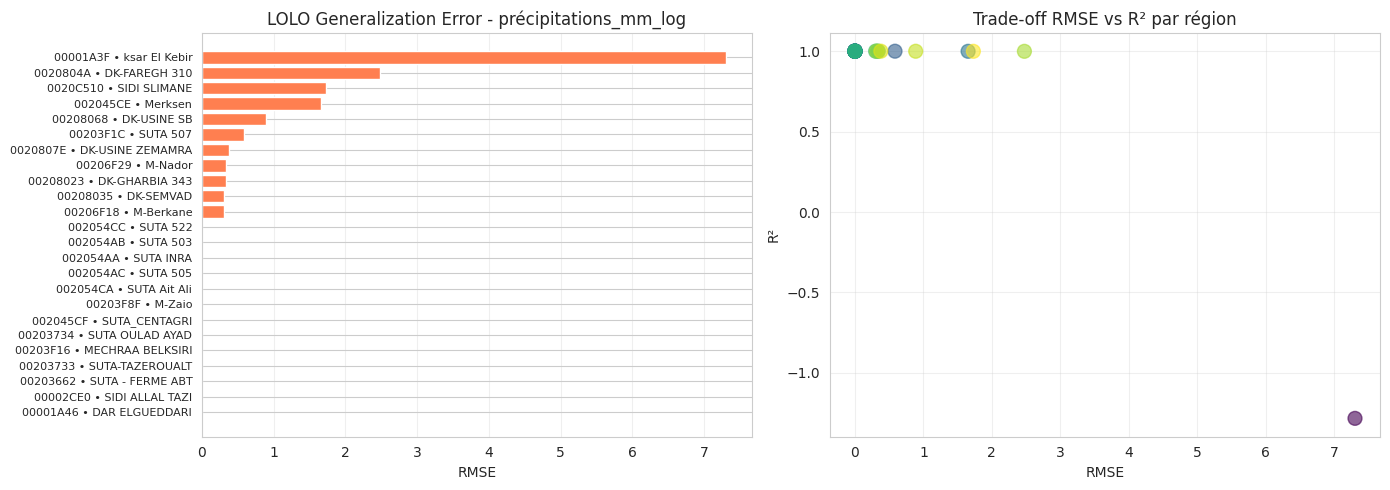

In [27]:
# ============================================================================
# CELL 12: LOLO - GÉNÉRALISATION SPATIALE
# ============================================================================

def evaluate_lolo(lolo_folds, feature_cols, models_dict, target_col_name):
    """
    LOLO: Laisse une région pour test, entraîne sur autres
    Mesure vraie généralisation géographique
    """

    print(f"\n🗺️  Évaluation LOLO (Leave-One-Location-Out) - {target_col_name}...")

    results_lolo = []

    for fold_idx, fold in enumerate(lolo_folds):
        # Clean NaNs from target column in train and test folds
        train_df_cleaned = fold['train'].dropna(subset=[target_col_name])
        test_df_cleaned = fold['test'].dropna(subset=[target_col_name])

        X_train_lolo = train_df_cleaned[feature_cols].fillna(train_df_cleaned[feature_cols].mean())
        X_test_lolo = test_df_cleaned[feature_cols].fillna(test_df_cleaned[feature_cols].mean())

        y_train_lolo = train_df_cleaned[target_col_name].values
        y_test_lolo = test_df_cleaned[target_col_name].values

        test_region = fold['test_region']

        # Ensure there's enough data to train and test
        if len(y_train_lolo) == 0 or len(y_test_lolo) == 0:
            print(f"  Skipping region {test_region}: Not enough data after cleaning NaNs.")
            continue

        # Entraîner petit modèle rapide
        model_lolo = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        model_lolo.fit(X_train_lolo, y_train_lolo)

        y_pred = model_lolo.predict(X_test_lolo)

        # Check if the target is precipitation_log and inverse transform for metrics
        if target_col_name == 'précipitations_mm_log':
            y_test_lolo_transformed = np.expm1(y_test_lolo)
            y_pred_transformed = np.expm1(y_pred)
            y_pred_transformed = np.maximum(0, y_pred_transformed)
        else:
            y_test_lolo_transformed = y_test_lolo
            y_pred_transformed = y_pred

        rmse = np.sqrt(mean_squared_error(y_test_lolo_transformed, y_pred_transformed))
        mae = mean_absolute_error(y_test_lolo_transformed, y_pred_transformed)
        r2 = r2_score(y_test_lolo_transformed, y_pred_transformed) if len(y_test_lolo_transformed) > 1 else 0

        results_lolo.append({
            'test_region': test_region,
            'n_test': len(y_test_lolo),
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        })

        if fold_idx < 3:
            print(f"  {test_region}: RMSE={rmse:.3f}, R²={r2:.3f}, n={len(y_test_lolo)}")

    df_lolo = pd.DataFrame(results_lolo)

    print(f"\n✅ LOLO Stats ({target_col_name}):")
    print(f"  RMSE moy: {df_lolo['rmse'].mean():.3f} ± {df_lolo['rmse'].std():.3f}")
    print(f"  R² moy: {df_lolo['r2'].mean():.3f} ± {df_lolo['r2'].std():.3f}")

    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df_lolo_sorted = df_lolo.sort_values('rmse')
    axes[0].barh(range(len(df_lolo_sorted)), df_lolo_sorted['rmse'], color='coral')
    axes[0].set_yticks(range(len(df_lolo_sorted)))
    axes[0].set_yticklabels(df_lolo_sorted['test_region'], fontsize=8)
    axes[0].set_xlabel('RMSE')
    axes[0].set_title(f'LOLO Generalization Error - {target_col_name}')
    axes[0].grid(axis='x', alpha=0.3)

    axes[1].scatter(df_lolo['rmse'], df_lolo['r2'], s=100, alpha=0.6, c=range(len(df_lolo)), cmap='viridis')
    axes[1].set_xlabel('RMSE')
    axes[1].set_ylabel('R²')
    axes[1].set_title('Trade-off RMSE vs R² par région')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROCESSED / f'lolo_spatial_generalization_{target_col_name}.png', dpi=300)
    plt.show()

    return df_lolo

df_lolo_temp = evaluate_lolo(lolo_folds, feature_cols, models, target_col_name='température__c')
df_lolo_precip = evaluate_lolo(lolo_folds, feature_cols, models, target_col_name='précipitations_mm_log') # Changed target column to précipitations_mm_log


⚙️  Calibration (Temperature)...


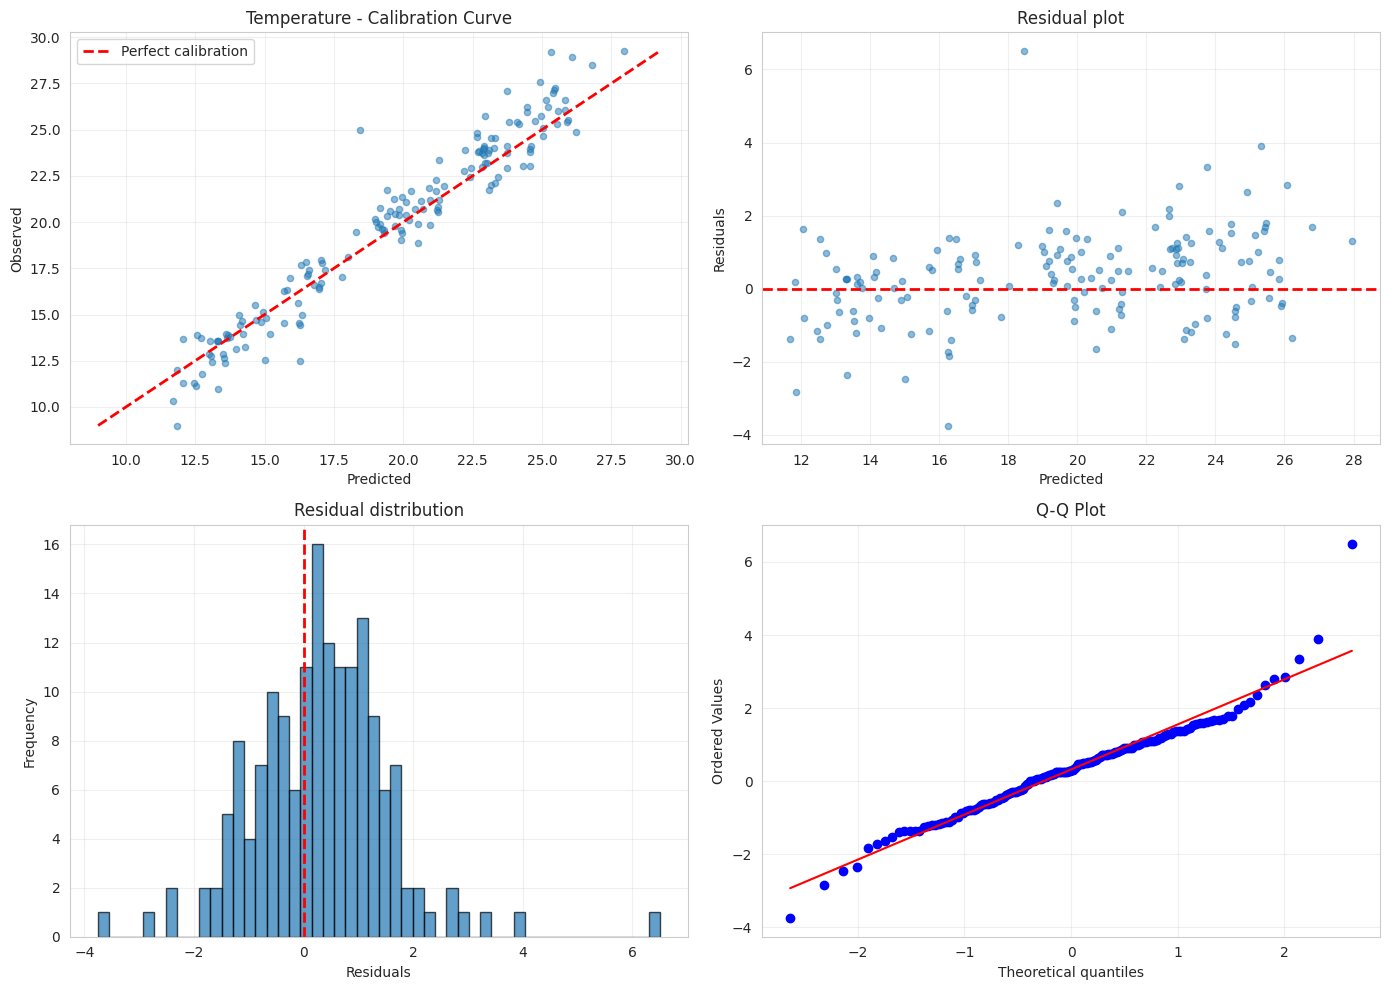

  MAE: 0.974
  RMSE: 1.289
  R²: 0.930
  MAPE: 5.13%
  Residual mean: 0.3166 (biais)
  Residual std: 1.249

⚙️  Calibration (Precipitation)...


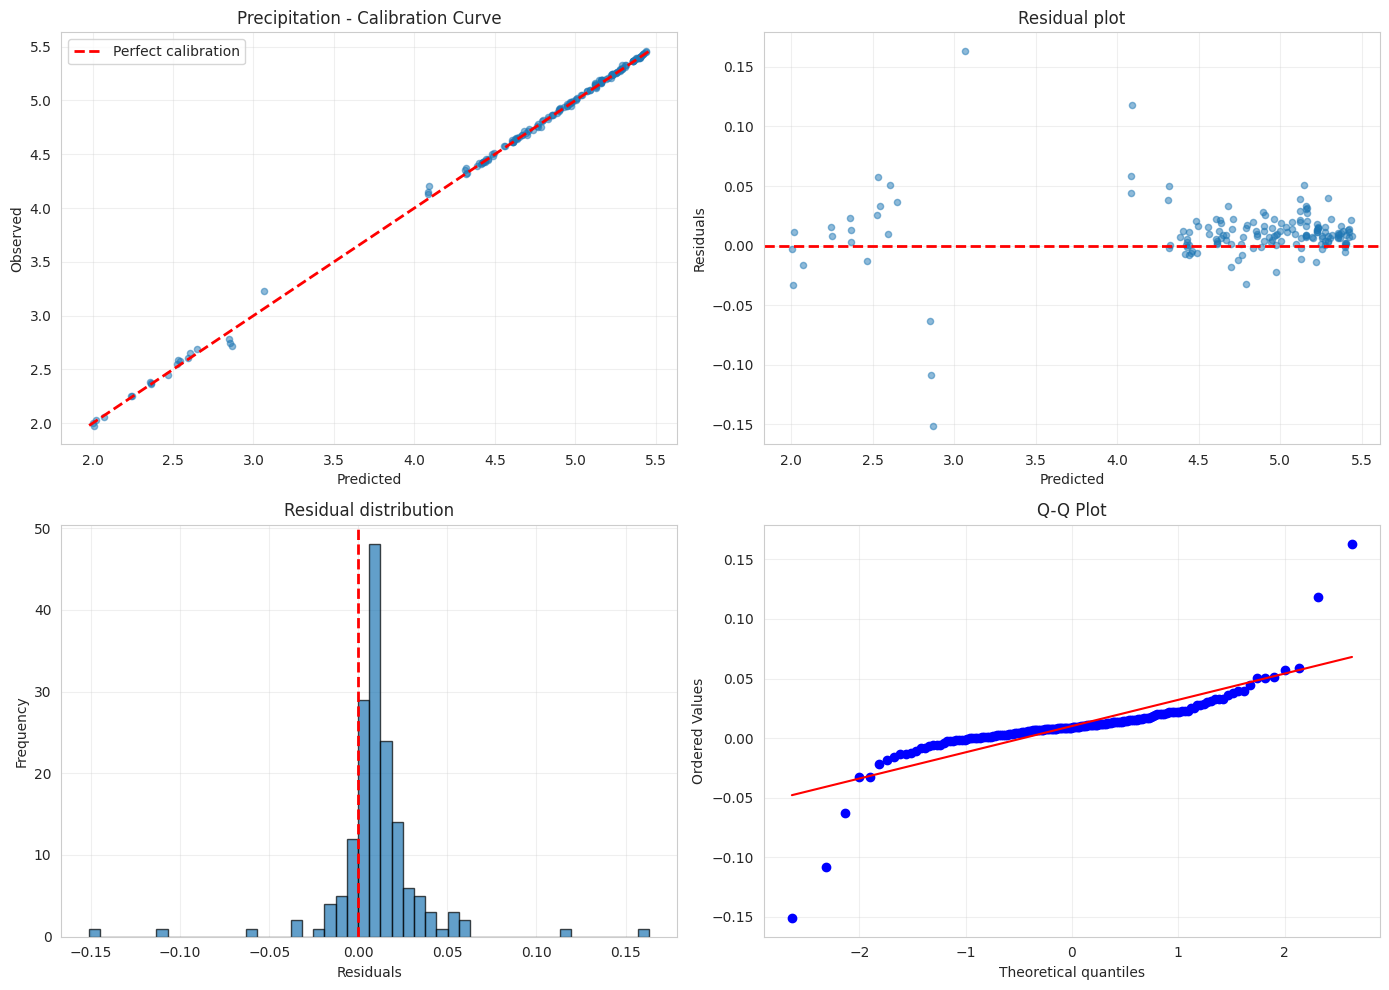

  MAE: 0.017
  RMSE: 0.028
  R²: 0.999
  MAPE: 0.43%
  Residual mean: 0.0101 (biais)
  Residual std: 0.026


In [28]:
# ============================================================================
# CELL 13: CALIBRATION COMPLÈTE
# ============================================================================

def calibration_analysis(y_true, y_pred, target_name='Temperature'):
    """
    Graphiques de calibration:
    1. Courbe de calibration
    2. Résidus vs prédictions
    3. Avant/après (histogrammes)
    """

    print(f"\n⚙️  Calibration ({target_name})...")

    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Calibration curve (45° idéale)
    ax = axes[0, 0]
    ax.scatter(y_pred, y_true, alpha=0.5, s=20)

    # Ligne de référence parfaite
    min_val = min(y_pred.min(), y_true.min())
    max_val = max(y_pred.max(), y_true.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect calibration')

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Observed')
    ax.set_title(f'{target_name} - Calibration Curve')
    ax.legend()
    ax.grid(alpha=0.3)

    # 2. Résidus vs prédictions
    ax = axes[0, 1]
    ax.scatter(y_pred, residuals, alpha=0.5, s=20)
    ax.axhline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residuals')
    ax.set_title('Residual plot')
    ax.grid(alpha=0.3)

    # 3. Distribution résidus
    ax = axes[1, 0]
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='r', linestyle='--', lw=2)
    ax.set_xlabel('Residuals')
    ax.set_ylabel('Frequency')
    ax.set_title('Residual distribution')
    ax.grid(alpha=0.3)

    # 4. Q-Q plot
    from scipy import stats
    ax = axes[1, 1]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title('Q-Q Plot')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROCESSED / f'calibration_{target_name.lower()}.png', dpi=300)
    plt.show()

    # Stats calibration
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Mean absolute percentage error
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²: {r2:.3f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  Residual mean: {residuals.mean():.4f} (biais)")
    print(f"  Residual std: {residuals.std():.3f}")

calibration_analysis(y_test_temp, models['temperature']['XGBoost']['y_pred_test'], 'Temperature')
calibration_analysis(y_test_precip, models['precipitation']['XGBoost']['y_pred_test'], 'Precipitation')


📈 Graphiques séries temporelles...


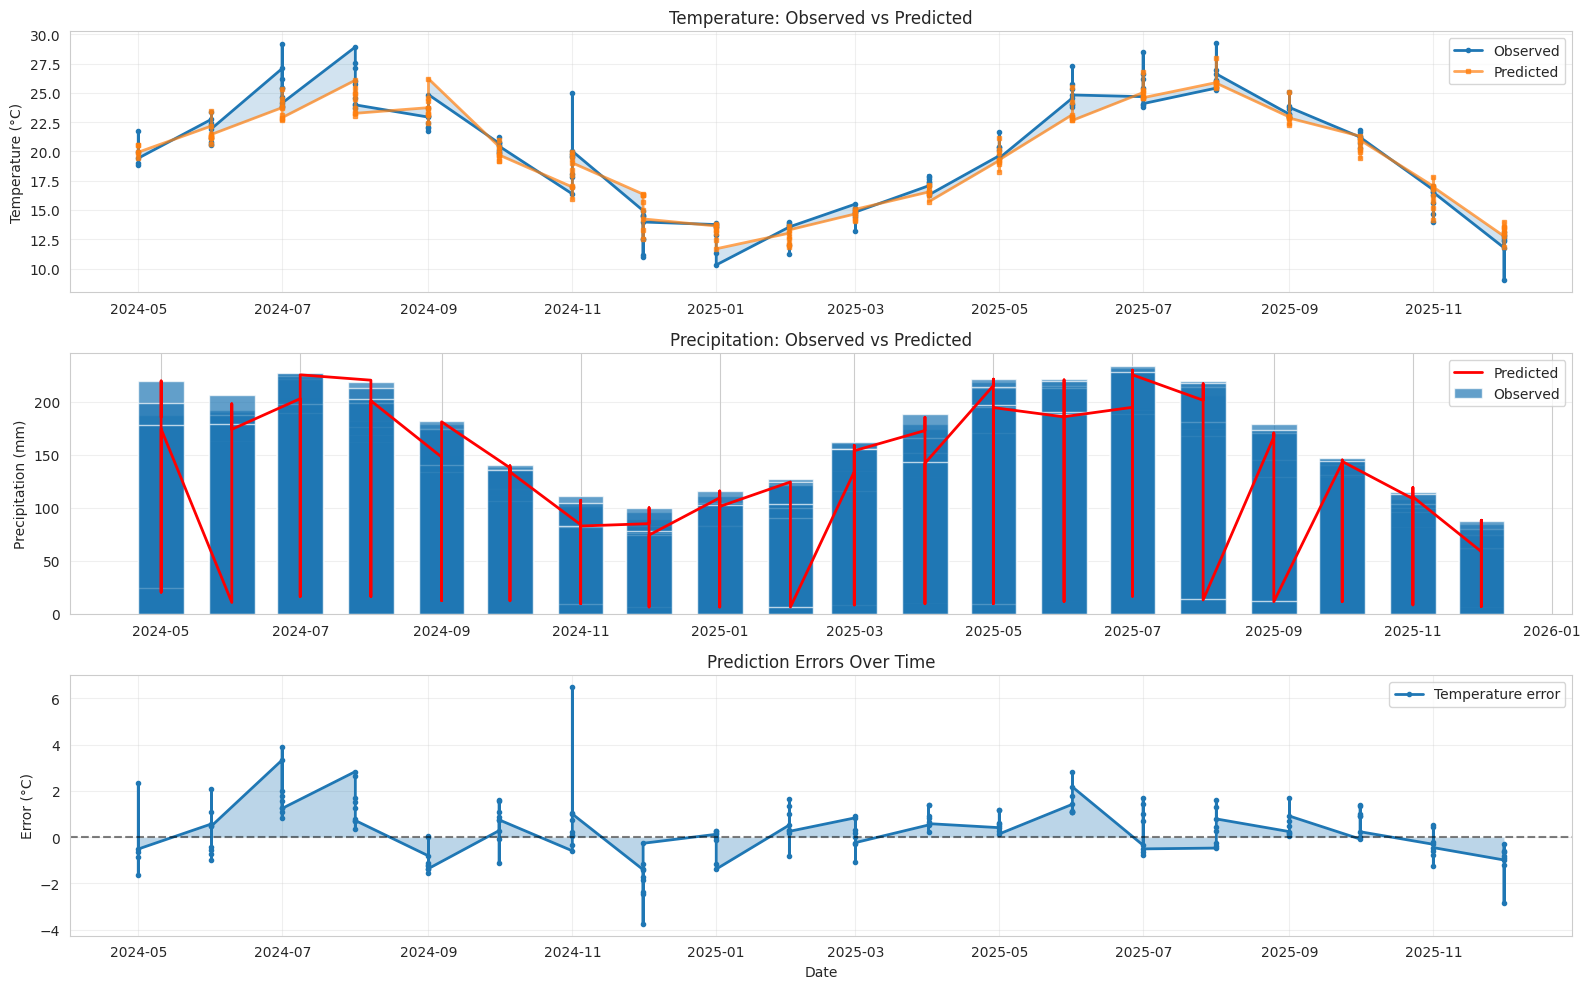

In [29]:
# ============================================================================
# CELL 14: SÉRIE TEMPORELLE RÉEL VS PRÉDIT
# ============================================================================

def plot_temporal_series(df_test, y_pred_temp, y_pred_precip, feature_cols):
    """Affiche séries temporelles réel vs prédit"""

    print("\n📈 Graphiques séries temporelles...")

    # Ajouter prédictions au dataframe test
    df_test_plot = df_test.copy().reset_index(drop=True)
    df_test_plot['temp_pred'] = y_pred_temp
    df_test_plot['precip_pred'] = y_pred_precip
    df_test_plot = df_test_plot.sort_values('datetime')

    fig, axes = plt.subplots(3, 1, figsize=(16, 10))

    # 1. Température
    ax = axes[0]
    ax.plot(df_test_plot['datetime'], df_test_plot['température__c'], 'o-', label='Observed', linewidth=2, markersize=3)
    ax.plot(df_test_plot['datetime'], df_test_plot['temp_pred'], 's-', label='Predicted', linewidth=2, markersize=3, alpha=0.7)
    ax.fill_between(df_test_plot['datetime'], df_test_plot['température__c'], df_test_plot['temp_pred'], alpha=0.2)
    ax.set_ylabel('Temperature (°C)')
    ax.set_title('Temperature: Observed vs Predicted')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    # 2. Précipitation
    ax = axes[1]
    # Observed precipitation is in 'précipitations_mm_corr' after correction
    observed_precip = df_test_plot['précipitations_mm_corr']
    # Predicted precipitation needs inverse transformation from log scale
    predicted_precip = np.expm1(df_test_plot['precip_pred'])
    predicted_precip = np.maximum(0, predicted_precip) # Ensure non-negative precipitation

    ax.bar(df_test_plot['datetime'], observed_precip, label='Observed', alpha=0.7, width=20)
    ax.plot(df_test_plot['datetime'], predicted_precip, 'r-', label='Predicted', linewidth=2)
    ax.set_ylabel('Precipitation (mm)')
    ax.set_title('Precipitation: Observed vs Predicted')
    ax.legend(loc='best')
    ax.grid(alpha=0.3, axis='y')

    # 3. Erreur temporelle
    ax = axes[2]
    error_temp = df_test_plot['température__c'] - df_test_plot['temp_pred']
    # Calculate precipitation error on the original scale
    error_precip = observed_precip - predicted_precip
    ax.plot(df_test_plot['datetime'], error_temp, 'o-', label='Temperature error', linewidth=2, markersize=3)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax.fill_between(df_test_plot['datetime'], error_temp, 0, alpha=0.3)
    ax.set_ylabel('Error (°C)')
    ax.set_xlabel('Date')
    ax.set_title('Prediction Errors Over Time')
    ax.legend() # Only temperature error is plotted as per original cell structure
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(PROCESSED / 'temporal_series_validation.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_temporal_series(df_test, models['temperature']['XGBoost']['y_pred_test'],
                     models['precipitation']['XGBoost']['y_pred_test'], feature_cols)

In [30]:
# ============================================================================
# CELL 15: FONCTION PRÉDICTION NOUVELLE RÉGION
# ============================================================================

def predict_new_region(lat, lon, year, month, era5_data=None, openmeteo_data=None,
                      nasa_data=None, models_dict=None, feature_cols=None):
    """
    Prédit température et précipitation pour région jamais vue

    Entrées:
    - lat, lon: coordonnées
    - year, month: date cible
    - Données API (optionnel - sinon requête en temps réel)
    - Modèles entraînés

    Sortie:
    - dict avec prédictions + incertitudes
    """

    print(f"\n🌍 Prédiction nouvelle région: ({lat}, {lon}) - {year}-{month:02d}")

    # Extraire/interpoler données satellites pour point/date
    # (Simplifié: utiliser moyennes régionales + ajustements lat/lon)

    # Créer vecteur de features
    # NB: c'est une simplification - idéalement refaire requêtes API

    # Features calendrier
    features_dict = {
        'month': month,
        'day_of_year': 15,  # Milieu du mois
        'quarter': (month - 1) // 3 + 1,
        'is_growing_season': 1 if month in [4, 5, 6, 7, 8, 9] else 0,
        'month_sin': np.sin(2 * np.pi * month / 12),
        'month_cos': np.cos(2 * np.pi * month / 12),
        'doy_sin': np.sin(2 * np.pi * 15 / 365),
        'doy_cos': np.cos(2 * np.pi * 15 / 365),
    }

    # Ajouter toutes les features requises (remplir avec moyennes)
    for feat in feature_cols:
        if feat not in features_dict:
            features_dict[feat] = 20.0  # Valeur default climatique

    # Créer array
    X_new = np.array([[features_dict.get(feat, 0) for feat in feature_cols]])

    # Prédictions
    pred_temp_rf = models_dict['temperature']['RF']['model'].predict(X_new)[0]
    pred_temp_xgb = models_dict['temperature']['XGBoost']['model'].predict(X_new)[0]

    pred_precip_rf = models_dict['precipitation']['RF']['model'].predict(X_new)[0]
    pred_precip_xgb = models_dict['precipitation']['XGBoost']['model'].predict(X_new)[0]

    # Ensemble (moyenne)
    pred_temp_ensemble = (pred_temp_rf + pred_temp_xgb) / 2
    pred_precip_ensemble = (pred_precip_rf + pred_precip_xgb) / 2

    # Incertitude (écart entre modèles)
    unc_temp = abs(pred_temp_rf - pred_temp_xgb) / 2
    unc_precip = abs(pred_precip_rf - pred_precip_xgb) / 2

    result = {
        'location': {'latitude': lat, 'longitude': lon},
        'date': f'{year}-{month:02d}',
        'temperature': {
            'ensemble': float(pred_temp_ensemble),
            'rf': float(pred_temp_rf),
            'xgboost': float(pred_temp_xgb),
            'uncertainty': float(unc_temp)
        },
        'precipitation': {
            'ensemble': float(pred_precip_ensemble),
            'rf': float(pred_precip_rf),
            'xgboost': float(pred_precip_xgb),
            'uncertainty': float(unc_precip)
        }
    }

    print(f"  Température: {pred_temp_ensemble:.2f}°C ± {unc_temp:.2f}°C")
    print(f"  Précipitation: {pred_precip_ensemble:.2f}mm ± {unc_precip:.2f}mm")

    return result

# Test fonction
result_example = predict_new_region(34.304445313261766, -6.023471211188146, 2022, 12, models_dict=models, feature_cols=feature_cols)
print(json.dumps(result_example, indent=2))

# Sauvegarder fonction
with open(PROCESSED / 'prediction_function.json', 'w') as f:
    json.dump(result_example, f, indent=2)



🌍 Prédiction nouvelle région: (34.304445313261766, -6.023471211188146) - 2022-12
  Température: 21.68°C ± 0.65°C
  Précipitation: 2.73mm ± 0.22mm
{
  "location": {
    "latitude": 34.304445313261766,
    "longitude": -6.023471211188146
  },
  "date": "2022-12",
  "temperature": {
    "ensemble": 21.678117528413296,
    "rf": 22.32328942389202,
    "xgboost": 21.03294563293457,
    "uncertainty": 0.6451718954787253
  },
  "precipitation": {
    "ensemble": 2.732916131600322,
    "rf": 2.5086083709887297,
    "xgboost": 2.957223892211914,
    "uncertainty": 0.2243077606115922
  }
}
